# **Laboratorio # 1 – Derivados Financieros**
**Portafolio LLY · ORCL · GD y cobertura con opciones listadas**

| Bloque | Contenido | Puntos de la rúbrica |
|---|---|---|
| I | Datos, curva de tasas, media-varianza, riesgo | 1 – 6 |
| II | MGB correlacionado con varianza GARCH, VaR sin y con cobertura teórica | 7, 8, 11, 12 |
| III | Opciones de mercado, binomial europeo/americano, estrategias A/B/C, MTM trimestral, presupuesto | 13 – 24 (y 12 correctivo) |

**Problema de inversión:** Se tienen 10 millones para invertir 2 años en tres acciones (Eli Lilly, Oracle y General Dynamics). Se quiere crecer, pero, se quiere cubrir el riesgo de que una mala racha destruya el capital. Por eso se decide comprar "seguros" con opciones sobre el 85 % de acciones.

Este notebook responde cuatro preguntas en orden:

- Cómo repartimos el dinero? (Bloque I)
- Cuánto podríamos perder? (Bloque II)
- Qué seguro compramos? (Bloque III)
- Valió la pena lo que se pagó por ese seguro? (Bloque III)


### Criterios financieros iniciales

| Criterio del enunciado | Implementación en este cuaderno |
|---|---|
| "Pago trimestral" = puntos de control | Las opciones se **revaloran a mercado** en cada cierre trimestral (3.10) con una regla explícita *mantener / ajustar / renovar*. |
| Tasa libre de riesgo por plazo | Curva Treasury 3M-6M-1Y-2Y (FRED) → función `r_plazo(T)`: cada opción se valora con la tasa de **su** vencimiento; el Sharpe usa el plazo del horizonte (2 años). |
| Portafolio como subyacente | Las opciones son sobre cada acción: contratos por activo (85 % de sus acciones) y luego se agrega el P&L al portafolio. |
| Europea vs americana | Árbol binomial CRR con los **mismos** $S_0, K, T, \sigma, r, q$ para ambas (3.4); la diferencia es el valor del ejercicio anticipado. |
| Sin apalancamiento | La prima se paga con caja propia del inversionista, fuera de los USD 10 M invertidos en acciones; el P&L cubierto se mide contra el desembolso total (acciones + prima). Se reporta el costo de oportunidad de esa caja a la tasa del plazo. |

In [ ]:
import warnings
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import scipy.stats as st
from scipy.optimize import minimize, brentq
from arch import arch_model
import yfinance as yf
from IPython.display import display

warnings.filterwarnings("ignore")
OUT = Path("Laboratorio 1 - docs"); OUT.mkdir(exist_ok=True)
pct = mtick.PercentFormatter(1.0, decimals=0)
musd = mtick.FuncFormatter(lambda v, _: f"${v/1e6:,.1f}M")

In [2]:
# Criterios de Inversión
TICKERS         = ["LLY", "ORCL", "GD"]
START           = "2021-10-01"
END             = datetime.today().strftime("%Y-%m-%d")   # yfinance excluye 'end' -> último cierre completo
CAPITAL         = 10_000_000
HORIZONTE_ANIOS = 2
COBERTURA       = 0.85
TAM_CONTRATO    = 100                                     # acciones por contrato listado en E.E.U.U.
DIAS_ANIO       = 252

# Portafolio
TIPO_RETORNO = "log"
W_MIN        = 0.15            # exigido por el laboratorio
W_MAX        = 0.50            # límite de concentración: política del equipo (ver 1.4)
CRITERIO     = "min_var"       # "min_var" | "max_sharpe"

# Tasas
TENOR_SHARPE   = 2.0                                                     # Rf del Sharpe = Bono del tesoro de E.E.U.U. del horizonte de inversión
CURVA_RESPALDO = {0.25: 0.0424, 0.5: 0.0434, 1.0: 0.0451, 2.0: 0.0487}   # TCM FRED establecida por default el 2026-09-24, solo si url de FRED no responde

SEED = 42
pd.options.display.float_format = "{:,.4f}".format
assert len(TICKERS) == 3 and W_MIN * 3 < 1 < W_MAX * 3

---
## **Bloque I – Construcción del portafolio media-varianza**
### 1.1 Fuentes y preparación de datos

In [3]:
DESCARGA_UTC = datetime.now(timezone.utc)
raw = yf.download(TICKERS, start=START, end=END, auto_adjust=False, progress=False)

close_raw = raw["Close"][TICKERS].copy()       # sin ajuste por dividendos -> spot para opciones
adj_raw   = raw["Adj Close"][TICKERS].copy()   # ajustado por dividendos   -> retornos totales

close_f, adj_f = close_raw.ffill(limit=3), adj_raw.ffill(limit=3)
mask = close_f.notna().all(axis=1) & adj_f.notna().all(axis=1)
close, adj = close_f[mask], adj_f[mask]

calidad = pd.DataFrame({
    "primera_fecha":   close_raw.apply(lambda s: s.first_valid_index().date()),
    "ultima_fecha":    close_raw.apply(lambda s: s.last_valid_index().date()),
    "obs_descargadas": close_raw.notna().sum(),
    "datos_faltantes": close_raw.isna().sum(),
    "obs_utilizadas":  len(close),
})
print(f"Descarga (UTC): {DESCARGA_UTC:%Y-%m-%d %H:%M:%S} | fechas en malla: {len(close_raw)} | "
      f"utilizadas: {len(close)} | eliminadas: {len(close_raw) - len(close)}")
display(calidad)
assert pd.Timestamp(close.index[0]) <= pd.Timestamp(START) + pd.Timedelta(days=5), "La serie no arranca en 01/10/2021"

Descarga (UTC): 2026-09-26 23:41:42 | fechas en malla: 1251 | utilizadas: 1251 | eliminadas: 0


,primera_fecha,ultima_fecha,obs_descargadas,datos_faltantes,obs_utilizadas
Ticker,,,,,
LLY,2021-10-01,2026-09-25,1251,0,1251
ORCL,2021-10-01,2026-09-25,1251,0,1251
GD,2021-10-01,2026-09-25,1251,0,1251


In [4]:
def meta_ticker(t):
    try:
        info = yf.Ticker(t).info or {}
    except Exception:
        info = {}
    return {"ticker": t, "empresa": info.get("longName", "n/d"), "sector": info.get("sector", "n/d"),
            "industria": info.get("industry", "n/d"),
            "mercado": info.get("fullExchangeName", info.get("exchange", "n/d")), "moneda": info.get("currency", "USD")}

def dividendos_ticker(t):
    try:
        d = yf.Ticker(t).dividends
        if getattr(d.index, "tz", None) is not None:
            d.index = d.index.tz_localize(None)
        return d
    except Exception:
        return pd.Series(dtype=float)

metadatos = pd.DataFrame([meta_ticker(t) for t in TICKERS]).set_index("ticker")
divs = {t: dividendos_ticker(t) for t in TICKERS}
metadatos["fuente_precios_y_dividendos"] = f"Yahoo Finance (yfinance {yf.__version__})"
metadatos["descarga_utc"] = f"{DESCARGA_UTC:%Y-%m-%d %H:%M}"
metadatos["serie_retornos"] = f"{TIPO_RETORNO} diarios sobre Adj Close"
display(metadatos)

,empresa,sector,industria,mercado,moneda,fuente_precios_y_dividendos,descarga_utc,serie_retornos
ticker,,,,,,,,
LLY,Eli Lilly and Company,Healthcare,Drug Manufacturers - General,NYSE,USD,Yahoo Finance (yfinance 1.7.0),2026-09-26 23:41,log diarios sobre Adj Close
ORCL,Oracle Corporation,Technology,Software - Infrastructure,NYSE,USD,Yahoo Finance (yfinance 1.7.0),2026-09-26 23:41,log diarios sobre Adj Close
GD,General Dynamics Corporation,Industrials,Aerospace & Defense,NYSE,USD,Yahoo Finance (yfinance 1.7.0),2026-09-26 23:41,log diarios sobre Adj Close


**Decisiones de datos**
- **Adj Close** (ajustado por dividendos y *splits*) para retornos: mide el retorno total que recibe el accionista.

- **Close** (solo *splits*) para el *spot* de las opciones: los contratos se liquidan contra el precio de mercado, y el dividendo se trata aparte mediante $q$. Mezclarlos subvaloraría las puts (el dividendo ya estaría "dentro" del precio).

- **Retornos logarítmicos**: son aditivos en el tiempo (el retorno a 2 años es la suma de los diarios), son la variable que modela el MGB ($\ln S$ es normal) y la entrada natural del GARCH.

- **Faltantes**: *forward fill* de máximo 3 días hábiles y eliminación de fechas sin dato común, para que la covarianza se estime sobre fechas alineadas.

### 1.2 Curva libre de riesgo por plazo y tasa de dividendo
Los TCM se cotizan con capitalización semestral (BEY). Se convierten a tasa continua $r_{cc} = 2\ln(1 + y/2)$, que es la que usan Black-Scholes y el árbol binomial. `r_plazo(T)` interpola linealmente la curva para el vencimiento exacto de cada opción.

In [5]:
SERIES_TSY = {0.25: "DGS3MO", 0.5: "DGS6MO", 1.0: "DGS1", 2.0: "DGS2"}

def fred_ultimo(serie):
    df = pd.read_csv(f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={serie}", na_values=".").dropna()
    return pd.to_datetime(df.iloc[-1, 0]).date(), float(df.iloc[-1, 1]) / 100

filas = []
for plazo, serie in SERIES_TSY.items():
    try:
        fecha, y = fred_ultimo(serie); fuente = f"FRED {serie}"
    except Exception:
        fecha, y, fuente = None, CURVA_RESPALDO[plazo], "respaldo manual (FRED no disponible)"
    filas.append({"plazo_anios": plazo, "fecha_dato": fecha, "TCM_BEY": y, "r_continua": 2 * np.log(1 + y / 2), "fuente": fuente})
curva_tsy = pd.DataFrame(filas).set_index("plazo_anios")
display(curva_tsy)

def r_plazo(T):
    # Tasa continua libre de riesgo para un plazo T en años (interpolación lineal, extrapolación plana)
    return float(np.interp(T, curva_tsy.index.values, curva_tsy["r_continua"].values))

RF_CC = r_plazo(TENOR_SHARPE)
print(f"Rf del Sharpe (Treasury {TENOR_SHARPE:.0f} años): {RF_CC:.4%} continua")

,fecha_dato,TCM_BEY,r_continua,fuente
plazo_anios,,,,
0.2500,2026-09-24,0.0424,0.0420,FRED DGS3MO
0.5000,2026-09-24,0.0434,0.0429,FRED DGS6MO
1.0000,2026-09-24,0.0451,0.0446,FRED DGS1
2.0000,2026-09-24,0.0487,0.0481,FRED DGS2


Rf del Sharpe (Treasury 2 años): 4.8117% continua


In [6]:
F_VAL = close.index[-1]           # fecha de valoración = último cierre utilizado
spot  = close.iloc[-1]            # spot NO ajustado
div_12m  = pd.Series({t: float(divs[t][divs[t].index > F_VAL - pd.Timedelta(days=365)].sum()) for t in TICKERS})
q_simple = div_12m / spot
q_div    = np.log(1 + q_simple)   # rendimiento por dividendo continuo (entrada de BS y del árbol)
display(pd.DataFrame({"spot_S0": spot, "dividendos_12m_por_accion": div_12m, "q_simple": q_simple, "q_continua": q_div}))
print(f"Fecha de valoración: {F_VAL:%Y-%m-%d}")

,spot_S0,dividendos_12m_por_accion,q_simple,q_continua
LLY,"1,183.4600",6.6900,0.0057,0.0056
ORCL,137.1000,2.0000,0.0146,0.0145
GD,336.7200,6.1800,0.0184,0.0182


Fecha de valoración: 2026-09-25


### 1.3 Retornos, volatilidades y correlaciones anualizadas
$\mu_i = 252\,\bar r_i$, $\;\Sigma = 252\,\text{Cov}(r)$, $\;\sigma_i = \sqrt{\Sigma_{ii}}$. Como $\bar r$ es la media de retornos **log**, $\mu$ es una tasa de crecimiento continua (mediana), comparable con $r_{cc}$.

In [7]:
rets = np.log(adj).diff().dropna() if TIPO_RETORNO == "log" else adj.pct_change().dropna()
mu, cov = rets.mean() * DIAS_ANIO, rets.cov() * DIAS_ANIO
vol, corr = np.sqrt(np.diag(cov.values)), rets.corr()

stats = pd.DataFrame({"retorno_anual": mu, "vol_anual": vol, "sharpe": (mu - RF_CC) / vol,
                      "asimetria": rets.skew(), "curtosis_exceso": rets.kurt()})
print(f"Retornos: {len(rets)} | {rets.index[0]:%Y-%m-%d} a {rets.index[-1]:%Y-%m-%d}")
display(stats.style.format({"retorno_anual": "{:.2%}", "vol_anual": "{:.2%}", "sharpe": "{:.3f}",
                            "asimetria": "{:.3f}", "curtosis_exceso": "{:.2f}"}).set_caption("Estadísticas anualizadas"))
display(cov.style.format("{:.5f}").set_caption("Covarianza anualizada"))
display(corr.style.format("{:.3f}").set_caption("Correlaciones"))

Retornos: 1250 | 2021-10-04 a 2026-09-25


,retorno_anual,vol_anual,sharpe,asimetria,curtosis_exceso
Ticker,,,,,
LLY,33.98%,32.61%,0.894,0.163,7.88
ORCL,9.90%,42.93%,0.119,1.240,17.48
GD,12.80%,20.73%,0.385,0.080,5.21


Ticker,LLY,ORCL,GD
Ticker,,,
LLY,0.10631,0.01858,0.01311
ORCL,0.01858,0.18429,0.01534
GD,0.01311,0.01534,0.04296


Ticker,LLY,ORCL,GD
Ticker,,,
LLY,1.000,0.133,0.194
ORCL,0.133,1.000,0.172
GD,0.194,0.172,1.000


### 1.4 Optimización media-varianza con peso mínimo de 15% y peso máximo del 50%
$$\min_w\; w^\top \Sigma w \quad \text{s.a.}\quad \textstyle\sum_i w_i = 1,\;\; 0.15 \le w_i \le 0.50$$

- El piso de 15 % es la regla del laboratorio.
- El **tope de 50 %** es una regla adicional del equipo (límite de concentración): sin él, el máximo Sharpe concentra más de 60 % en LLY y esa sola acción pasa a explicar más del 80 % de la volatilidad. La tabla muestra ambos casos para que el costo quede cuantificado.

In [8]:
n = len(TICKERS)
mu_v, cov_m = mu.values, cov.values
cons_sum = {"type": "eq", "fun": lambda w: np.sum(w) - 1}
x0, OPT = np.full(n, 1 / n), {"ftol": 1e-12, "maxiter": 2000}

ret_p    = lambda w: float(w @ mu_v)
vol_p    = lambda w: float(np.sqrt(w @ cov_m @ w))
sharpe_p = lambda w: (ret_p(w) - RF_CC) / vol_p(w)

def optimizar(obj, w_max):
    r = minimize(obj, x0, method="SLSQP", bounds=[(W_MIN, w_max)] * n, constraints=[cons_sum], options=OPT)
    assert r.success, r.message
    return r.x

w_minvar = optimizar(lambda w: w @ cov_m @ w, W_MAX)
w_sharpe = optimizar(lambda w: -sharpe_p(w), W_MAX)
w_maxret = optimizar(lambda w: -ret_p(w), W_MAX)
w_sharpe_libre = optimizar(lambda w: -sharpe_p(w), 1 - 2 * W_MIN)   # sensibilidad: sin tope de concentración

frontera = []
for tr in np.linspace(ret_p(w_minvar), ret_p(w_maxret), 60):
    cons = [cons_sum, {"type": "eq", "fun": lambda w, tr=tr: ret_p(w) - tr}]
    r = minimize(lambda w: w @ cov_m @ w, x0, method="SLSQP", bounds=[(W_MIN, W_MAX)] * n, constraints=cons, options=OPT)
    if r.success:
        frontera.append({"retorno": tr, "volatilidad": vol_p(r.x)})
frontera = pd.DataFrame(frontera)

rng = np.random.default_rng(SEED)
W = W_MIN + (1 - n * W_MIN) * rng.dirichlet(np.ones(n), size=20_000)
W = W[(W <= W_MAX).all(axis=1)]
nube = pd.DataFrame({"retorno": W @ mu_v, "volatilidad": np.sqrt(np.einsum("ij,jk,ik->i", W, cov_m, W))})
nube["sharpe"] = (nube["retorno"] - RF_CC) / nube["volatilidad"]

def rc_pct(w):
    return w * (cov_m @ w) / (w @ cov_m @ w)

comparativo = pd.DataFrame({
    nombre: {**{f"w_{t}": x for t, x in zip(TICKERS, w)}, "retorno": ret_p(w), "vol": vol_p(w), "sharpe": sharpe_p(w),
             "max_%riesgo_1_activo": rc_pct(w).max()}
    for nombre, w in [("Pesos iguales", x0), ("Mínima varianza", w_minvar), ("Máximo Sharpe", w_sharpe),
                      ("Máx. Sharpe sin tope 50 %", w_sharpe_libre)]}).T
display(comparativo.style.format("{:.2%}", subset=[c for c in comparativo.columns if c != "sharpe"]).format("{:.3f}", subset=["sharpe"]))

ELEGIDOS = {"min_var": (w_minvar, "Mínima varianza"), "max_sharpe": (w_sharpe, "Máximo Sharpe")}
w_star, NOMBRE_ELEGIDO = ELEGIDOS[CRITERIO]
assert np.isclose(w_star.sum(), 1) and (w_star >= W_MIN - 1e-8).all()
print(f"Portafolio elegido: {NOMBRE_ELEGIDO} -> " + ", ".join(f"{t} {x:.1%}" for t, x in zip(TICKERS, w_star)))
print(f"Retorno {ret_p(w_star):.2%} | volatilidad {vol_p(w_star):.2%} | Sharpe {sharpe_p(w_star):.3f}")
print("Restricciones activas:", {t: ("piso" if np.isclose(x, W_MIN, atol=1e-5) else "techo" if np.isclose(x, W_MAX, atol=1e-5) else "libre")
                                 for t, x in zip(TICKERS, w_star)})

,w_LLY,w_ORCL,w_GD,retorno,vol,sharpe,max_%riesgo_1_activo
Pesos iguales,33.33%,33.33%,33.33%,18.89%,21.80%,0.646,51.03%
Mínima varianza,33.13%,16.87%,50.00%,19.33%,19.15%,0.758,40.59%
Máximo Sharpe,50.00%,15.00%,35.00%,22.95%,21.21%,0.855,67.30%
Máx. Sharpe sin tope 50 %,69.76%,15.00%,15.24%,27.14%,25.35%,0.881,85.71%


Portafolio elegido: Mínima varianza -> LLY 33.1%, ORCL 16.9%, GD 50.0%
Retorno 19.33% | volatilidad 19.15% | Sharpe 0.758
Restricciones activas: {'LLY': 'libre', 'ORCL': 'libre', 'GD': 'techo'}


**¿Por qué mínima varianza y no máximo Sharpe?** El máximo Sharpe gana ~0.1 de Sharpe, pero lo hace cargando el activo con el retorno histórico más alto (LLY, +34 % anual). 

La mínima varianza tiene dos ventajas concretas: (1) no depende de estimaciones de retorno esperado, que son el insumo más ruidoso de Markowitz, y (2) sobrepondera GD, la acción de menor volatilidad, lo que abarata la cobertura porque la prima de una put crece con la volatilidad del subyacente. 

Cambiar `CRITERIO = "max_sharpe"` re-ejecutar todo el cuaderno con la otra cartera (hacer la prueba). 

### 1.5 Contribución al riesgo y Sharpe
$$RC_i = w_i\frac{(\Sigma w)_i}{\sigma_p},\qquad \textstyle\sum_i RC_i = \sigma_p,\qquad \%RC_i = RC_i/\sigma_p$$

In [9]:
sig_p = vol_p(w_star)
riesgo = pd.DataFrame({"peso": w_star, "vol_individual": vol, "RC_pct": rc_pct(w_star)}, index=TICKERS)
riesgo["RC_pct / peso"] = riesgo["RC_pct"] / riesgo["peso"]
assert np.isclose(riesgo["RC_pct"].sum(), 1.0)
display(riesgo.style.format({"peso": "{:.1%}", "vol_individual": "{:.1%}", "RC_pct": "{:.1%}", "RC_pct / peso": "{:.2f}"}))

ACTIVO_DOMINANTE = riesgo["RC_pct"].idxmax()
print(f"Activo que domina el riesgo: {ACTIVO_DOMINANTE} ({riesgo.loc[ACTIVO_DOMINANTE, 'RC_pct']:.1%} de la volatilidad "
      f"con {riesgo.loc[ACTIVO_DOMINANTE, 'peso']:.1%} del capital)")
print(f"Beneficio de diversificación: vol. ponderada {float(w_star @ vol):.2%} vs vol. del portafolio {sig_p:.2%}")

,peso,vol_individual,RC_pct,RC_pct / peso
LLY,33.1%,32.6%,40.6%,1.23
ORCL,16.9%,42.9%,20.7%,1.23
GD,50.0%,20.7%,38.7%,0.77


Activo que domina el riesgo: LLY (40.6% de la volatilidad con 33.1% del capital)
Beneficio de diversificación: vol. ponderada 28.41% vs vol. del portafolio 19.15%


### 1.6 Del peso a las acciones y a los contratos (datos para los Bloques II y III)
Se compran acciones **enteras** (piso) y se dimensionan contratos para cubrir ≈85 % de cada posición; el porcentaje efectivo difiere por el multiplicador de 100 que es la base establecida por contrato.

In [10]:
acciones     = np.floor(w_star * CAPITAL / spot.values)
invertido    = acciones * spot.values
efectivo     = CAPITAL - invertido.sum()
portafolio_0 = float(invertido.sum())

contratos_85       = np.round(COBERTURA * acciones / TAM_CONTRATO)
cobertura_efectiva = contratos_85 * TAM_CONTRATO / acciones

asignacion = pd.DataFrame({"peso_objetivo": w_star, "spot_S0": spot.values, "acciones": acciones.astype(int),
                           "USD_invertido": invertido, "peso_efectivo": invertido / portafolio_0,
                           "contratos_85%": contratos_85.astype(int), "cobertura_efectiva": cobertura_efectiva}, index=TICKERS)
display(asignacion.style.format({"peso_objetivo": "{:.2%}", "peso_efectivo": "{:.2%}", "cobertura_efectiva": "{:.2%}",
                                 "spot_S0": "{:,.2f}", "USD_invertido": "${:,.0f}"}))
print(f"Invertido: USD {portafolio_0:,.2f} | efectivo residual: USD {efectivo:,.2f} | "
      f"cobertura por valor: {(contratos_85 * TAM_CONTRATO * spot.values).sum() / portafolio_0:.2%}")
assert (asignacion["peso_efectivo"] >= W_MIN - 1e-6).all()

,peso_objetivo,spot_S0,acciones,USD_invertido,peso_efectivo,contratos_85%,cobertura_efectiva
LLY,33.13%,"1,183.46",2799,"$3,312,504",33.13%,24,85.74%
ORCL,16.87%,137.10,12304,"$1,686,878",16.87%,105,85.34%
GD,50.00%,336.72,14849,"$4,999,955",50.00%,126,84.85%


Invertido: USD 9,999,338.20 | efectivo residual: USD 661.80 | cobertura por valor: 85.23%


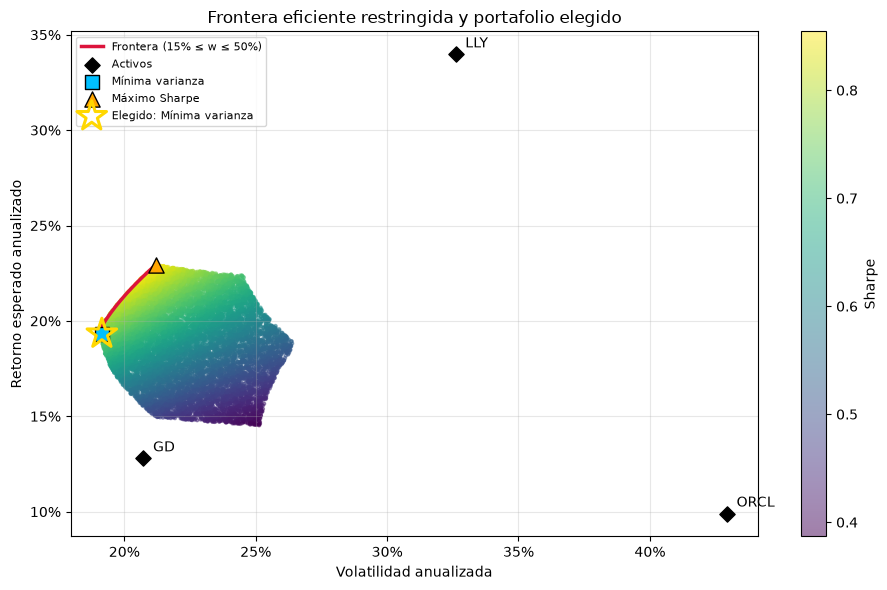

In [11]:
fig, ax = plt.subplots(figsize=(9.5, 6))
sc = ax.scatter(nube["volatilidad"], nube["retorno"], c=nube["sharpe"], cmap="viridis", s=5, alpha=0.5)
plt.colorbar(sc, ax=ax, label="Sharpe")
ax.plot(frontera["volatilidad"], frontera["retorno"], color="crimson", lw=2.5, label=f"Frontera ({W_MIN:.0%} ≤ w ≤ {W_MAX:.0%})")
ax.scatter(vol, mu_v, marker="D", s=60, color="black", zorder=5, label="Activos")
for t, v, m in zip(TICKERS, vol, mu_v):
    ax.annotate(t, (v, m), textcoords="offset points", xytext=(7, 5))
ax.scatter(vol_p(w_minvar), ret_p(w_minvar), marker="s", s=110, color="deepskyblue", edgecolor="k", zorder=7, label="Mínima varianza")
ax.scatter(vol_p(w_sharpe), ret_p(w_sharpe), marker="^", s=120, color="orange", edgecolor="k", zorder=7, label="Máximo Sharpe")
ax.scatter(vol_p(w_star), ret_p(w_star), marker="*", s=500, facecolor="none", edgecolor="gold", linewidth=2.2, zorder=8,
           label=f"Elegido: {NOMBRE_ELEGIDO}")
ax.xaxis.set_major_formatter(pct); ax.yaxis.set_major_formatter(pct)
ax.set_xlabel("Volatilidad anualizada"); ax.set_ylabel("Retorno esperado anualizado")
ax.set_title("Frontera eficiente restringida y portafolio elegido"); ax.legend(fontsize=8, loc="upper left"); ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig(OUT / "fig1_frontera_eficiente.png", dpi=170); plt.show()

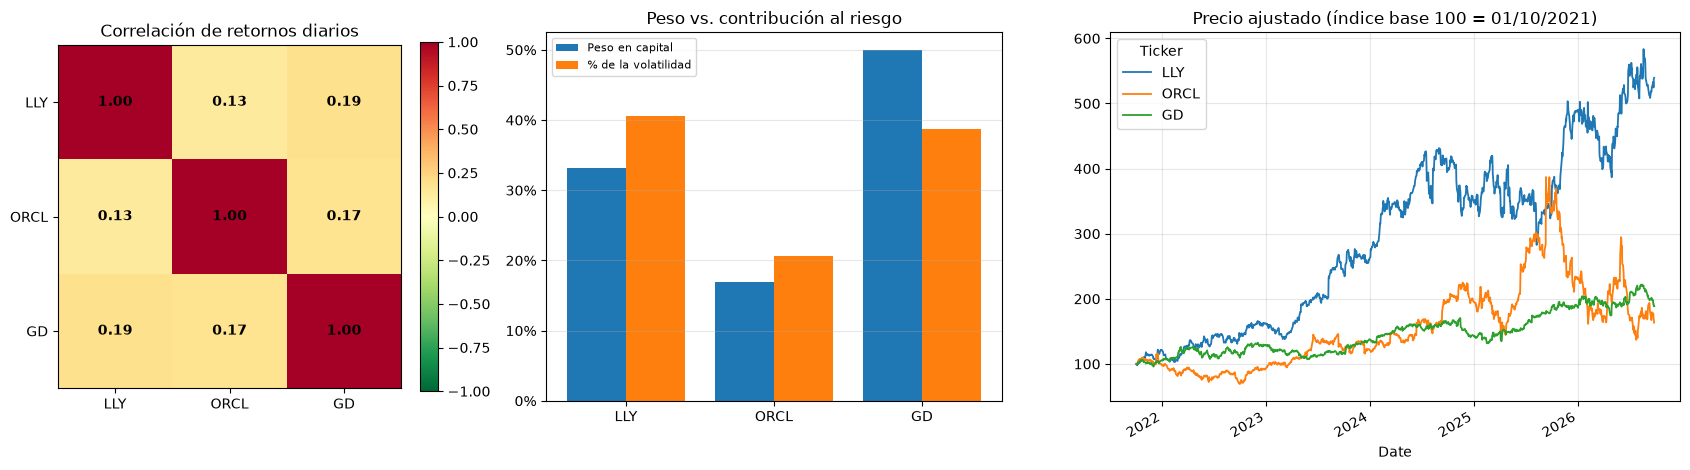

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8), gridspec_kw={"width_ratios": [1, 1.2, 1.5]})
im = axes[0].imshow(corr.values, cmap="RdYlGn_r", vmin=-1, vmax=1)
axes[0].set_xticks(range(n)); axes[0].set_yticks(range(n)); axes[0].set_xticklabels(TICKERS); axes[0].set_yticklabels(TICKERS)
for i in range(n):
    for j in range(n):
        axes[0].text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontweight="bold")
axes[0].set_title("Correlación de retornos diarios"); plt.colorbar(im, ax=axes[0], fraction=0.046)

x = np.arange(n)
axes[1].bar(x - 0.2, riesgo["peso"], 0.4, label="Peso en capital")
axes[1].bar(x + 0.2, riesgo["RC_pct"], 0.4, label="% de la volatilidad")
axes[1].set_xticks(x); axes[1].set_xticklabels(TICKERS); axes[1].yaxis.set_major_formatter(pct)
axes[1].set_title("Peso vs. contribución al riesgo"); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3, axis="y")

(adj / adj.iloc[0] * 100).plot(ax=axes[2], lw=1.3)
axes[2].set_title("Precio ajustado (índice base 100 = 01/10/2021)"); axes[2].grid(alpha=0.3)
fig.tight_layout(); fig.savefig(OUT / "fig2_correlaciones_riesgo_precios.png", dpi=170); plt.show()

**Lectura de los gráficos.** Las correlaciones entre 0.13 y 0.19 son bajas porque los tres negocios responden a motores distintos (farmacéutica, software/nube, defensa): eso es lo que baja la volatilidad del portafolio a ~19 % frente a ~28 % si los riesgos simplemente se sumaran. En el panel de riesgo, una barra naranja más alta que la azul indica que el activo aporta más riesgo que capital: LLY y ORCL aportan ≈1.2 veces su peso, GD solo ≈0.8. El índice base 100 incluye dividendos reinvertidos (precio ajustado) y deja ver que el retorno de LLY es atípico dentro de la muestra.

> ### **🧠 Bloque I – Cómo repartimos nuestros USD 10 millones?** 
> #### **Paso 1:** 
> Descargamos cinco años de precios, desde el 01/10/2021 y usamos dos precios distintos para dos casos diferentes: El precio ajustado (Adj Close) para medir cuánto se gana históricamente, incluye los dividendos que también se pagan, porque, ese dinero también es ganancia. El precio normal (Close) para las opciones. Un contrato de opción se liquida contra el precio que ve el mercado hoy, y ese precio baja cada vez que la empresa paga un dividendo. Si usaramos el ajustado, la acción vale más de lo que vale en sí y el seguro nos saldría mal calculado.
>  
> La **fórmula** utilizada para calcular los rendimientos de cada día $r_t = \ln \big(\frac{P_t}{P_{t-1}}\big)$.  
>
> #### **Paso 2:** 
> La tasa libre de riesgo es lo que ganaríamos sin riesgo si le prestaramos al gobierno de EE. UU., se extraen varias tasas correspondientes a su peridodo de tiempo, pero la que nos interesa es a 2 años y paga alrededor de $4.87\%$.
>  
> 1. Para calcular nuestro portafolio se utilizó la tasa continua a 2 años.
> 2. Para calcular una opción con vencimiento como por ejemplo a 16 meses pues se utiliza una tasa correspondiente al vencimiento de la opción.
>
> Esto nos conviene, ya que, se calcula con su tasa correcta o acertada a la variable en cuestión, no se deja como por defecto una regla para medir tantas cantidades de variables, lo que estaríamos incurriendo en un cálculo menos acertado. 
>
> Los dividendos los convertimos a una tasa anual, $q$: LLY paga 0.56%, ORCL paga 1.42%, GD paga 1.82%. La tasa de dividendos se necesita, ya que, abarata lo que son las opciones cally encarece las opciones puts, porque, su precio cae cuando se pagan.
>
> #### **Paso 3:**
>
> En este paso medimos como se comportó cada acción, es decir, su rendimiento y volatilidad anual. LLY fue nuestra acción estrella la que obtuvo mejor rendimiento individual, pero no sabemos, si es probable que vuelve a repetir tal movimiento explosivo, ORCL es la acción que menos rendimiento generó y con mayor volatilidad, en el otro caso está GD es la acción más tranquila con respecto a las otras. Las correlaciones de estos activos es baja, entre 0.13 y 0.19, esto significa que cuando cae una acción las otras no caen al mismo ritmo, ya que, vienen de sectores distintos, esta fue nuestra primera decisión de protección.
>
> #### **Paso 4:** 
> 
> En este paso se cálcula nuestra optimización para el portafolio mediante Markowitz $\sigma_p = w^\top \Sigma w$ para calcular la volatilidad del portafolio de acuerdo nuestras restricciones, en otras palabras, acá medimos el riesgo en conjunto y no por acción individual, ya que, nuestra cartera depende del movimiento en conjunto de las acciones.
> 
> Nuestra decisión de mínima varianza es porque decidimos renunciar a 0.1 de sharpe por tres sencillas razones:
>
> 1. El sharpe máximo depende de creer en que nuevamente la acción de LLY siga teniendo sus mismos rendimientos después de ese boom, como inversionistas llegamos a la conclusión de que el dato pasado en finanzas es el menos fiable.
> 2. Por el lado contrario el portafolio de mínima varianza no necesita fiarse de los rendimientos, en este caso, solo usamos volatilidad y correlación, estos datos son mucho más estables que los mismos rendimientos.
> 3. Ponemos la mitad de dinero en la acción más estable que es GD, por lo que proteger una acción sin tanto ruido cubrirla con una opción será mucho más barato, por lo mencionado anteriormente, el valor de la prima de acuerdo a su volatilidad.
> 
> #### **Paso 5:**
>   
> Acá medimos certadamente quien nos pone en riesgo de acuerdo a la contribución porcentual de efectivo dentro de la cartera, lo calmulamos mediante $RC_i = w_i\frac{(\sum w)_i}{\sigma p}$.
>
> #### **Paso 6:**
>
> Decidimos invertir en acciones enteras, esto tiene una implicación directa sobre la cobertura con opciones, porque, los contratos de opciones estandarizados controlan exactamente 100 acciones completas, por lo que la cobertura real con opciones estará alrededor del 85%. Por el otro lado, las acciones fraccionadas no se pueden cubrir de forma directa ni eficiente con opciones estándar, podríamos incurrir a sobrecostos. Siempre tendremos un sobrante en la caja o un efectivo residual. 

---
## **Bloque II – Simulación del portafolio y medición de riesgo**
Variables a usar del Bloque I: `acciones`, `spot`, `mu`, `vol`, `q_div`, `r_plazo`. La simulación es **diaria** y se observa en los cierres trimestrales.

In [13]:
N_PATHS          = 10_000
N_TRIMESTRES     = HORIZONTE_ANIOS * 4
PASOS_TRIMESTRE  = DIAS_ANIO // 4
N_DIAS_SIM       = N_TRIMESTRES * PASOS_TRIMESTRE                           # 504 días hábiles
IDX_TRIM         = np.arange(N_TRIMESTRES + 1) * PASOS_TRIMESTRE
ETQ_TRIM         = ["t=0"] + [f"T{i}" for i in range(1, N_TRIMESTRES + 1)]
HIST_GARCH_ANIOS = 10
N_PATHS_10Y      = 4_000

### 2.1 Varianza GARCH(1,1) con 10 años de historia
$$r_t = c + \varepsilon_t,\qquad \varepsilon_t = \sqrt{h_t}\,z_t,\qquad h_t = \omega + \alpha\,\varepsilon_{t-1}^2 + \beta\,h_{t-1},\qquad z_t \sim t_\nu \text{ estandarizada}$$

- Se estima por máxima verosimilitud sobre log-retornos ×100 (estabilidad numérica de `arch`) y se compara el AIC contra la versión normal.

- **Dependencia (CCC-GARCH, Bollerslev 1990):** la correlación se estima sobre los **residuos estandarizados** $z_t$ de los 10 años, no sobre retornos brutos: así la correlación no se contamina con los periodos de alta volatilidad.

- De los parámetros salen: persistencia $\alpha+\beta$, vida media de un choque $\ln 0.5/\ln(\alpha+\beta)$, volatilidad de largo plazo $\sqrt{\omega/(1-\alpha-\beta)}$ y la varianza de mañana $h_{T+1}$, punto de partida de la simulación.

In [14]:
START_GARCH = (F_VAL - pd.DateOffset(years=HIST_GARCH_ANIOS)).strftime("%Y-%m-%d")
raw_10y  = yf.download(TICKERS, start=START_GARCH, end=END, auto_adjust=False, progress=False)
adj_10y  = raw_10y["Adj Close"][TICKERS].ffill(limit=3).dropna()
rets_10y = np.log(adj_10y).diff().dropna()

PERSIST_MAX = 0.999                  # α+β ≥ 0.999 -> choque prácticamente permanente (IGARCH): no apto para simular
ESPECIFICACIONES = ["t", "normal"]   # candidatas; se elige la de menor AIC entre las estacionarias

def ajustar_garch(serie):
    intentos = []
    for dist in ESPECIFICACIONES:
        fit = arch_model(serie * 100, mean="Constant", vol="Garch", p=1, q=1, dist=dist).fit(disp="off")
        a, b = fit.params["alpha[1]"], fit.params["beta[1]"]
        intentos.append({"dist": dist, "fit": fit, "alpha": a, "beta": b, "alpha+beta": a + b,
                         "nu": fit.params.get("nu", np.inf), "AIC": fit.aic,
                         "estacionario": (a + b < PERSIST_MAX) and fit.convergence_flag == 0})
    validos = [x for x in intentos if x["estacionario"]]
    if not validos:
        raise ValueError(f"{serie.name}: ninguna especificación es estacionaria {[(x['dist'], round(x['alpha+beta'], 4)) for x in intentos]}. "
                         "Revisar saltos extremos en la serie o probar un GJR/EGARCH.")
    return min(validos, key=lambda x: x["AIC"]), intentos

garch_fits, filas, z_std, diag = {}, {}, {}, []
for t in TICKERS:
    elegido, intentos = ajustar_garch(rets_10y[t])
    fit = elegido["fit"]; garch_fits[t], z_std[t] = fit, fit.std_resid
    om, a, b = fit.params["omega"], elegido["alpha"], elegido["beta"]
    peor = rets_10y[t].abs().idxmax()
    for x in intentos:
        diag.append({"activo": t, "distribución": x["dist"], "alpha": x["alpha"], "beta": x["beta"], "alpha+beta": x["alpha+beta"],
                     "nu": x["nu"], "AIC": x["AIC"], "estacionario": x["estacionario"], "elegido": x is elegido,
                     "mayor_movimiento_diario": f"{rets_10y[t][peor]:+.1%} ({peor:%Y-%m-%d})"})
    filas[t] = {"omega": om, "alpha": a, "beta": b, "alpha+beta": a + b, "nu": elegido["nu"],
                "vida_media_choque_dias": np.log(0.5) / np.log(a + b),
                "vol_LP_anual": np.sqrt(om / (1 - a - b) / 1e4 * DIAS_ANIO),
                "vol_hoy_anual": np.sqrt(fit.forecast(horizon=1, reindex=False).variance.values[-1, 0] / 1e4 * DIAS_ANIO),
                "vol_hist_BloqueI": vol[TICKERS.index(t)], "AIC": fit.aic}
ESPEC_GARCH = {t: next(d["distribución"] for d in diag if d["activo"] == t and d["elegido"]) for t in TICKERS}
garch_resumen = pd.DataFrame(filas).T.astype(float)
corr_ccc = pd.DataFrame(z_std).dropna().corr()

display(pd.DataFrame(diag).set_index(["activo", "distribución"]).style
        .format({"alpha": "{:.4f}", "beta": "{:.4f}", "alpha+beta": "{:.4f}", "nu": "{:.2f}", "AIC": "{:,.0f}"})
        .set_caption("Diagnóstico de especificación GARCH(1,1)"))
display(garch_resumen.style.format("{:.4f}").format("{:.1%}", subset=["vol_LP_anual", "vol_hoy_anual", "vol_hist_BloqueI"])
        .format("{:,.0f}", subset=["AIC", "vida_media_choque_dias"]))
display(corr_ccc.style.format("{:.3f}").set_caption("Correlación CCC (residuos estandarizados, 10 años)"))
assert (garch_resumen["alpha+beta"] < PERSIST_MAX).all()
print("Especificación usada en la simulación:", ESPEC_GARCH)

,omega,alpha,beta,alpha+beta,nu,vida_media_choque_dias,vol_LP_anual,vol_hoy_anual,vol_hist_BloqueI,AIC
LLY,0.1704,0.1082,0.8613,0.9695,3.3619,22,37.5%,25.8%,32.6%,"9,504"
ORCL,0.2312,0.1468,0.8303,0.9771,inf,30,50.5%,45.8%,42.9%,"10,590"
GD,0.0450,0.0602,0.9177,0.9780,4.6526,31,22.7%,20.9%,20.7%,"8,204"


,LLY,ORCL,GD
LLY,1.000,0.171,0.212
ORCL,0.171,1.000,0.257
GD,0.212,0.257,1.000


Especificación usada en la simulación: {'LLY': 't', 'ORCL': 'normal', 'GD': 't'}


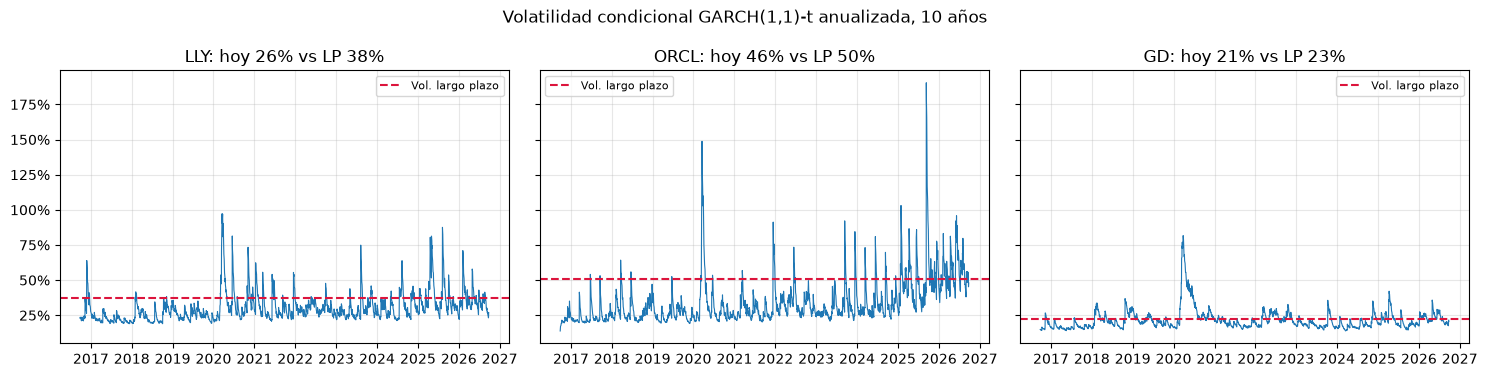

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8), sharey=True)
for ax, t in zip(axes, TICKERS):
    ax.plot(rets_10y.index, garch_fits[t].conditional_volatility / 100 * np.sqrt(DIAS_ANIO), lw=0.8)
    ax.axhline(garch_resumen.loc[t, "vol_LP_anual"], color="crimson", ls="--", label="Vol. largo plazo")
    ax.set_title(f"{t}: hoy {garch_resumen.loc[t, 'vol_hoy_anual']:.0%} vs LP {garch_resumen.loc[t, 'vol_LP_anual']:.0%}")
    ax.yaxis.set_major_formatter(pct); ax.legend(fontsize=8); ax.grid(alpha=0.3)
fig.suptitle("Volatilidad condicional GARCH(1,1)-t anualizada, 10 años"); fig.tight_layout()
fig.savefig(OUT / "fig3_volatilidad_garch.png", dpi=170); plt.show()

### 2.2 MGB correlacionado con varianza GARCH por trayectoria
Para cada activo $i$, día $t$ y trayectoria:
$$\ln S_{i,t+1} = \ln S_{i,t} + \Big(\underbrace{\tfrac{\mu_i + \tfrac12\sigma_i^2 - q_i}{252}}_{\text{deriva del precio}} - \tfrac12 h_{i,t}\Big) + \sqrt{h_{i,t}}\,z_{i,t},\qquad h_{i,t+1} = \omega_i + \alpha_i\,\varepsilon_{i,t}^2 + \beta_i\,h_{i,t}$$

- $\mu_i$ es la media **log** del Bloque I; $\mu_i + \sigma_i^2/2$ recupera el retorno aritmético y el término $-h_{i,t}/2$ es la corrección de Itô con la varianza **del día**. Si la volatilidad sube, la mediana crece menos, como debe ser.

- Se resta $q_i$ porque las opciones pagan sobre el precio, que cae con cada dividendo; el dividendo se acumula aparte como caja ($q_i S_{i,t}/252$ por día), así el valor del portafolio sigue siendo de retorno total.

- Choques: normales independientes → Cholesky de `corr_ccc` → cópula gaussiana → marginales $t_\nu$ estandarizadas del GARCH. La correlación y las colas gruesas quedan ambas incorporadas.

- La varianza **se actualiza con el choque simulado de cada trayectoria**: un escenario con una caída fuerte queda con volatilidad alta en los días siguientes (agrupamiento de volatilidad), que es justo lo que engorda la cola del VaR.

In [16]:
def simular_portafolio(n_paths, n_dias, idx_guardar, drift_log=None, seed=SEED):
    # Devuelve precios S (sin dividendo) y dividendos acumulados por acción D en los días idx_guardar
    rng = np.random.default_rng(seed)
    drift_log = mu.values if drift_log is None else np.asarray(drift_log, float)
    drift_d = (drift_log + 0.5 * vol**2 - q_div.values) / DIAS_ANIO
    om = garch_resumen["omega"].values.astype(float) / 1e4
    a, b = garch_resumen["alpha"].values.astype(float), garch_resumen["beta"].values.astype(float)
    h = np.tile((garch_resumen["vol_hoy_anual"].values.astype(float) ** 2) / DIAS_ANIO, (n_paths, 1))
    Lc = np.linalg.cholesky(corr_ccc.values)
    xs = np.linspace(-8, 8, 4001)
    tablas = [st.t.ppf(st.norm.cdf(xs), nu) * np.sqrt((nu - 2) / nu) if np.isfinite(nu) else xs
              for nu in garch_resumen["nu"].values.astype(float)]
    qd = q_div.values / DIAS_ANIO
    pos = {int(d): k for k, d in enumerate(idx_guardar)}
    S_out = np.empty((n_paths, len(idx_guardar), 3), np.float32); D_out = np.zeros_like(S_out)
    logS, div = np.tile(np.log(spot.values), (n_paths, 1)), np.zeros((n_paths, 3))
    if 0 in pos:
        S_out[:, pos[0]] = spot.values
    for d in range(1, n_dias + 1):
        x = rng.standard_normal((n_paths, 3)) @ Lc.T
        z = np.column_stack([np.interp(x[:, k], xs, tablas[k]) for k in range(3)])
        eps = np.sqrt(h) * z
        logS += drift_d - 0.5 * h + eps
        h = om + a * eps**2 + b * h
        S = np.exp(logS); div += qd * S
        if d in pos:
            S_out[:, pos[d]], D_out[:, pos[d]] = S, div
    return S_out, D_out

DIAS = np.arange(N_DIAS_SIM + 1)
S_all, D_all = simular_portafolio(N_PATHS, N_DIAS_SIM, DIAS)          # (N_PATHS, 505, 3): se reutiliza en el Bloque III
valor_nc = (S_all * acciones).sum(axis=2) + (D_all * acciones).sum(axis=2)   # acciones + dividendos cobrados
port_trim = valor_nc[:, IDX_TRIM]
assert np.allclose(port_trim[:, 0], portafolio_0, rtol=1e-6)
print(f"Trayectorias: {N_PATHS:,} | pasos diarios: {N_DIAS_SIM} | memoria: {(S_all.nbytes + D_all.nbytes)/1e6:,.0f} MB")

Trayectorias: 10,000 | pasos diarios: 504 | memoria: 121 MB


,fecha_aprox,media,P5,P25,P50,P75,P95,Prob(pérdida)
t=0,2026-09-25,"$9,999,338","$9,999,338","$9,999,338","$9,999,338","$9,999,338","$9,999,338",0.0%
T1,2026-12-23,"$10,626,000","$9,015,998","$9,914,937","$10,560,728","$11,247,748","$12,460,151",28.0%
T2,2027-03-22,"$11,284,342","$8,796,318","$10,173,233","$11,162,215","$12,244,951","$14,119,417",21.4%
T3,2027-06-17,"$12,006,669","$8,881,843","$10,511,434","$11,793,436","$13,234,481","$15,790,070",16.5%
T4,2027-09-14,"$12,738,474","$8,906,561","$10,883,791","$12,432,554","$14,195,354","$17,611,945",13.7%
T5,2027-12-10,"$13,537,757","$8,988,332","$11,328,834","$13,147,730","$15,287,949","$19,369,383",11.5%
T6,2028-03-08,"$14,397,954","$9,108,497","$11,739,992","$13,903,624","$16,413,480","$21,322,646",9.8%
T7,2028-06-05,"$15,335,753","$9,264,999","$12,267,360","$14,645,213","$17,620,780","$23,441,224",8.2%
T8,2028-08-31,"$16,330,857","$9,472,174","$12,703,344","$15,496,761","$18,887,547","$25,820,112",7.0%


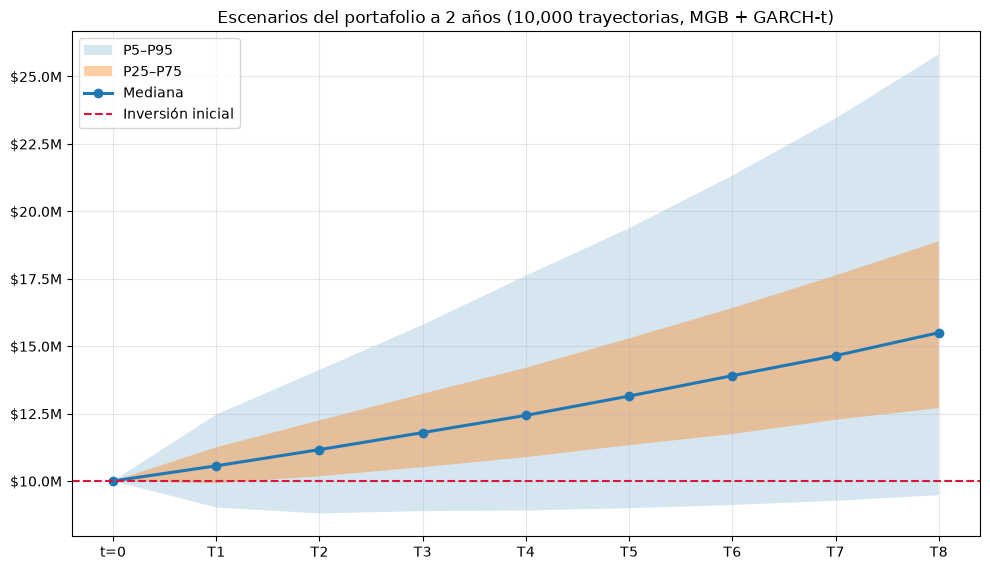

Escenarios, no pronóstico: a 2 años la mediana es $15,496,761 (+55.0%), pero 1 de cada 20 escenarios termina por debajo de $9,472,174
 y la probabilidad de perder capital es 7.0%.


In [17]:
fechas_trim = [F_VAL + pd.tseries.offsets.BDay(int(d)) for d in IDX_TRIM]
percentiles = [5, 25, 50, 75, 95]
tabla_trim = pd.DataFrame({"fecha_aprox": [f"{d:%Y-%m-%d}" for d in fechas_trim], "media": port_trim.mean(0),
                           **{f"P{p}": np.percentile(port_trim, p, axis=0) for p in percentiles},
                           "Prob(pérdida)": (port_trim < portafolio_0).mean(0)}, index=ETQ_TRIM)
display(tabla_trim.style.format({**{c: "${:,.0f}" for c in ["media"] + [f"P{p}" for p in percentiles]}, "Prob(pérdida)": "{:.1%}"}))

fig, ax = plt.subplots(figsize=(10, 5.8)); x = np.arange(N_TRIMESTRES + 1)
ax.fill_between(x, tabla_trim["P5"], tabla_trim["P95"], alpha=0.18, label="P5–P95")
ax.fill_between(x, tabla_trim["P25"], tabla_trim["P75"], alpha=0.38, label="P25–P75")
ax.plot(x, tabla_trim["P50"], marker="o", lw=2.2, label="Mediana")
ax.axhline(portafolio_0, color="crimson", ls="--", label="Inversión inicial")
ax.set_xticks(x); ax.set_xticklabels(ETQ_TRIM); ax.yaxis.set_major_formatter(musd)
ax.set_title(f"Escenarios del portafolio a {HORIZONTE_ANIOS} años ({N_PATHS:,} trayectorias, MGB + GARCH-t)")
ax.legend(loc="upper left"); ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig(OUT / "fig4_bandas_percentiles.png", dpi=170); plt.show()
m = tabla_trim.loc[f"T{N_TRIMESTRES}"]
print(f"Escenarios, no pronóstico: a {HORIZONTE_ANIOS} años la mediana es ${m['P50']:,.0f} ({m['P50']/portafolio_0-1:+.1%}), "
      f"pero 1 de cada 20 escenarios termina por debajo de ${m['P5']:,.0f}\n y la probabilidad de perder capital es {m['Prob(pérdida)']:.1%}.")

### 2.3 VaR y distribución de pérdidas – portafolio **no cubierto**
$$\text{VaR}_{95} = -Q_{0.05}(P\&L),\qquad \text{VaR}_{99} = -Q_{0.01}(P\&L),\qquad \text{ES}_{99} = -E[P\&L \mid P\&L \le Q_{0.01}]$$
$P\&L_t = V_t - V_0$, con $V_t$ = acciones + dividendos cobrados. Se reporta en T1 y al cierre de la ventana de 2 años (T8); en el Bloque III se añade el vencimiento real de las opciones.

,VaR95,VaR99,ES95,ES99,P&L_medio,VaR95_%,VaR99_%,ES99_%
T1,"$983,340","$1,694,381","$1,420,209","$2,119,594","$626,662",9.83%,16.94%,21.20%
T8,"$527,164","$2,332,406","$1,641,103","$3,128,661","$6,331,519",5.27%,23.33%,31.29%


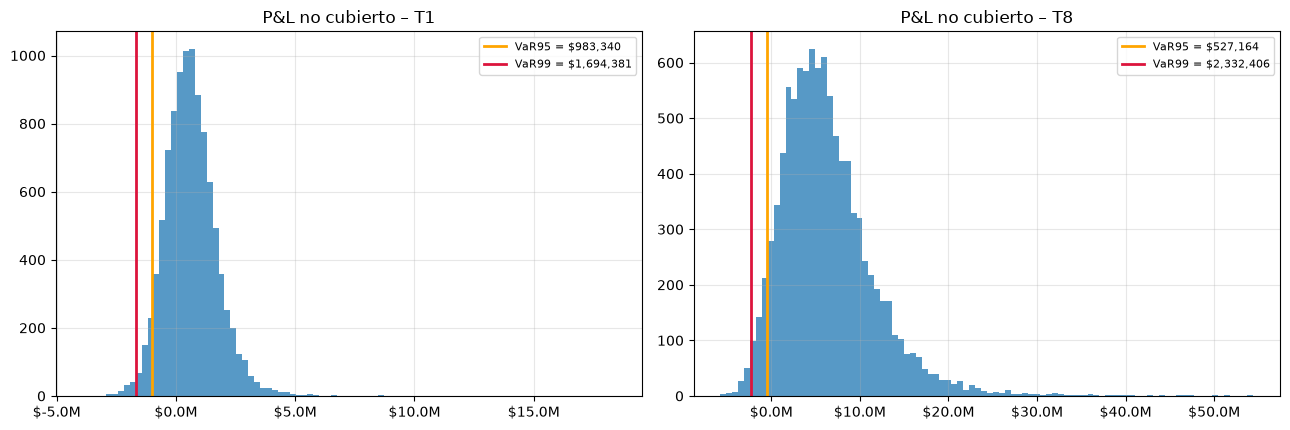

In [18]:
def metricas_riesgo(pnl):
    q5, q1 = np.percentile(pnl, 5), np.percentile(pnl, 1)
    return {"VaR95": -q5, "VaR99": -q1, "ES95": -pnl[pnl <= q5].mean(), "ES99": -pnl[pnl <= q1].mean(), "P&L_medio": pnl.mean()}

pnl_nc = {"T1": port_trim[:, 1] - portafolio_0, f"T{N_TRIMESTRES}": port_trim[:, -1] - portafolio_0}
tabla_var_nc = pd.DataFrame({k: metricas_riesgo(v) for k, v in pnl_nc.items()}).T
for c in ["VaR95", "VaR99", "ES99"]:
    tabla_var_nc[f"{c}_%"] = tabla_var_nc[c] / portafolio_0
display(tabla_var_nc.style.format("${:,.0f}").format("{:.2%}", subset=[c for c in tabla_var_nc if c.endswith("%")]))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
for ax, (k, pnl) in zip(axes, pnl_nc.items()):
    ax.hist(pnl, bins=90, alpha=0.75)
    for nivel, color in [("VaR95", "orange"), ("VaR99", "crimson")]:
        ax.axvline(-tabla_var_nc.loc[k, nivel], color=color, lw=2, label=f"{nivel} = ${tabla_var_nc.loc[k, nivel]:,.0f}")
    ax.set_title(f"P&L no cubierto – {k}"); ax.xaxis.set_major_formatter(musd); ax.legend(fontsize=8); ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig(OUT / "fig5_var_no_cubierto.png", dpi=170); plt.show()

**Sensibilidad a la deriva.** El VaR a 2 años es muy sensible a $\mu$: con la deriva histórica (LLY +34 % anual) el crecimiento esperado "tapa" buena parte de la cola. Se repite la simulación con una deriva conservadora igual a la tasa libre de riesgo (retorno total $= r$) para ver cuánto del riesgo aparente depende de suponer que el pasado se repite.

In [19]:
drift_rf = np.full(3, RF_CC) - 0.5 * vol**2          # media log compatible con retorno aritmético = Rf
S_rf, D_rf = simular_portafolio(N_PATHS, N_DIAS_SIM, IDX_TRIM, drift_log=drift_rf)
port_rf = (S_rf * acciones).sum(2) + (D_rf * acciones).sum(2)
sens = pd.DataFrame({
    "VaR95 deriva histórica": tabla_var_nc["VaR95"].values,
    "VaR95 deriva = Rf": [metricas_riesgo(port_rf[:, 1] - portafolio_0)["VaR95"], metricas_riesgo(port_rf[:, -1] - portafolio_0)["VaR95"]],
    "VaR99 deriva histórica": tabla_var_nc["VaR99"].values,
    "VaR99 deriva = Rf": [metricas_riesgo(port_rf[:, 1] - portafolio_0)["VaR99"], metricas_riesgo(port_rf[:, -1] - portafolio_0)["VaR99"]],
}, index=tabla_var_nc.index)
display(sens.style.format("${:,.0f}"))
del S_rf, D_rf

,VaR95 deriva histórica,VaR95 deriva = Rf,VaR99 deriva histórica,VaR99 deriva = Rf
T1,"$983,340","$1,401,667","$1,694,381","$2,065,232"
T8,"$527,164","$3,488,163","$2,332,406","$4,628,386"


### 2.4 VaR del portafolio cubierto – benchmark teórico
Antes de ir al mercado se mide cuánto riesgo quitaría una **protective put ATM a 2 años** sobre `contratos_85` de cada activo, valorada con Black-Scholes usando la volatilidad de largo plazo del GARCH, $r$ = `r_plazo(2)` y $q$ continua. La prima sale de caja propia en $t=0$; en cada cierre trimestral las puts se revaloran con el tiempo remanente. En el Bloque III este ejercicio se repite con los contratos, primas *bid/ask* y volatilidades implícitas reales, y la comparación entre ambos muestra cuánto cobra el mercado por encima del modelo.

In [20]:
def bs_precio(S, K, T, sigma, r, q, tipo="put"):
    S = np.asarray(S, float); T = np.maximum(np.asarray(T, float), 1e-12); sq = sigma * np.sqrt(T)
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / sq; d2 = d1 - sq
    if tipo == "call":
        return S * np.exp(-q * T) * st.norm.cdf(d1) - K * np.exp(-r * T) * st.norm.cdf(d2)
    return K * np.exp(-r * T) * st.norm.cdf(-d2) - S * np.exp(-q * T) * st.norm.cdf(-d1)

def bs_delta(S, K, T, sigma, r, q, tipo="put"):
    T = max(T, 1e-12); d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return np.exp(-q * T) * (st.norm.cdf(d1) - (tipo == "put"))

def intrinseco(S, K, tipo):
    return np.maximum(K - S, 0.0) if tipo == "put" else np.maximum(S - K, 0.0)

T_PRE, sig_pre, r_pre = float(HORIZONTE_ANIOS), garch_resumen["vol_LP_anual"].values.astype(float), r_plazo(HORIZONTE_ANIOS)
K_pre = spot.values.copy()
prima_pre_accion = np.array([bs_precio(spot.values[k], K_pre[k], T_PRE, sig_pre[k], r_pre, q_div.values[k]) for k in range(3)])
prima_pre = float((prima_pre_accion * contratos_85 * TAM_CONTRATO).sum())

puts_pre = np.zeros_like(port_trim)
for j, d in enumerate(IDX_TRIM):
    T_rem = T_PRE - d / DIAS_ANIO
    for k in range(3):
        S_k = S_all[:, d, k]
        v = intrinseco(S_k, K_pre[k], "put") if T_rem <= 1e-9 else bs_precio(S_k, K_pre[k], T_rem, sig_pre[k], r_plazo(T_rem), q_div.values[k])
        puts_pre[:, j] += contratos_85[k] * TAM_CONTRATO * v
pnl_pre = {"T1": port_trim[:, 1] + puts_pre[:, 1] - portafolio_0 - prima_pre,
           f"T{N_TRIMESTRES}": port_trim[:, -1] + puts_pre[:, -1] - portafolio_0 - prima_pre}
var_pre = pd.DataFrame({k: metricas_riesgo(v) for k, v in pnl_pre.items()}).T

comp_pre = pd.DataFrame({
    "VaR95 sin": tabla_var_nc["VaR95"], "VaR95 con": var_pre["VaR95"], "Δ VaR95": 1 - var_pre["VaR95"] / tabla_var_nc["VaR95"],
    "VaR99 sin": tabla_var_nc["VaR99"], "VaR99 con": var_pre["VaR99"], "Δ VaR99": 1 - var_pre["VaR99"] / tabla_var_nc["VaR99"],
    "ES99 sin": tabla_var_nc["ES99"], "ES99 con": var_pre["ES99"], "Δ ES99": 1 - var_pre["ES99"] / tabla_var_nc["ES99"]})
print(f"Prima teórica ATM 2 años: USD {prima_pre:,.0f} = {prima_pre / portafolio_0:.2%} del portafolio "
      f"({', '.join(f'{t} {p/s:.1%} del spot' for t, p, s in zip(TICKERS, prima_pre_accion, spot.values))})")
display(comp_pre.style.format("${:,.0f}").format("{:+.1%}", subset=["Δ VaR95", "Δ VaR99", "Δ ES99"]))

payoff_T8 = puts_pre[:, -1]
print(f"Probabilidad de que las puts paguen más que su prima al vencimiento: {(payoff_T8 > prima_pre).mean():.1%}")
for k_ in comp_pre.index:
    for nivel in ["VaR95", "VaR99", "ES99"]:
        if comp_pre.loc[k_, f"Δ {nivel}"] < 0:
            print(f"· {k_} {nivel}: la cobertura EMPEORA la métrica. El cuantil sin cubrir es una pérdida de "
                  f"${comp_pre.loc[k_, f'{nivel} sin']:,.0f}, menor que la prima (${prima_pre:,.0f}); en ese escenario "
                  f"las puts casi no están en el dinero y el costo domina. La protección solo trabaja en la cola más profunda.")

Prima teórica ATM 2 años: USD 1,185,626 = 11.86% del portafolio (LLY 16.1% del spot, ORCL 23.2% del spot, GD 9.3% del spot)


,VaR95 sin,VaR95 con,Δ VaR95,VaR99 sin,VaR99 con,Δ VaR99,ES99 sin,ES99 con,Δ ES99
T1,"$983,340","$634,744",+35.5%,"$1,694,381","$1,029,575",+39.2%,"$2,119,594","$1,200,875",+43.3%
T8,"$527,164","$421,204",+20.1%,"$2,332,406","$1,276,744",+45.3%,"$3,128,661","$1,433,100",+54.2%


Probabilidad de que las puts paguen más que su prima al vencimiento: 12.1%


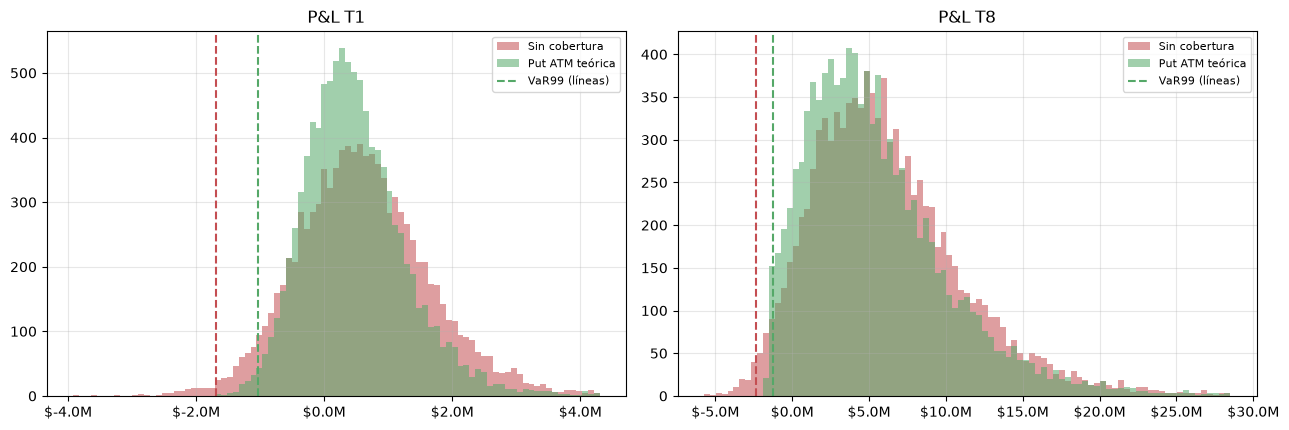

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
for ax, k in zip(axes, pnl_nc):
    bins = np.linspace(min(pnl_nc[k].min(), pnl_pre[k].min()), np.percentile(pnl_nc[k], 99.5), 90)
    ax.hist(pnl_nc[k], bins=bins, alpha=0.55, color="#c44e52", label="Sin cobertura")
    ax.hist(pnl_pre[k], bins=bins, alpha=0.55, color="#55a868", label="Put ATM teórica")
    ax.axvline(-tabla_var_nc.loc[k, "VaR99"], color="#c44e52", ls="--", lw=1.5)
    ax.axvline(-var_pre.loc[k, "VaR99"], color="#55a868", ls="--", lw=1.5, label="VaR99 (líneas)")
    ax.set_title(f"P&L {k}"); ax.xaxis.set_major_formatter(musd); ax.legend(fontsize=8); ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig(OUT / "fig6_var_cubierto_teorico.png", dpi=170); plt.show()

### 2.5 Vista estratégica a 10 años
Mismo motor (GARCH por trayectoria, dividendos como caja), 4.000 trayectorias. Es contexto: las decisiones de cobertura se toman sobre la ventana de 2 años.

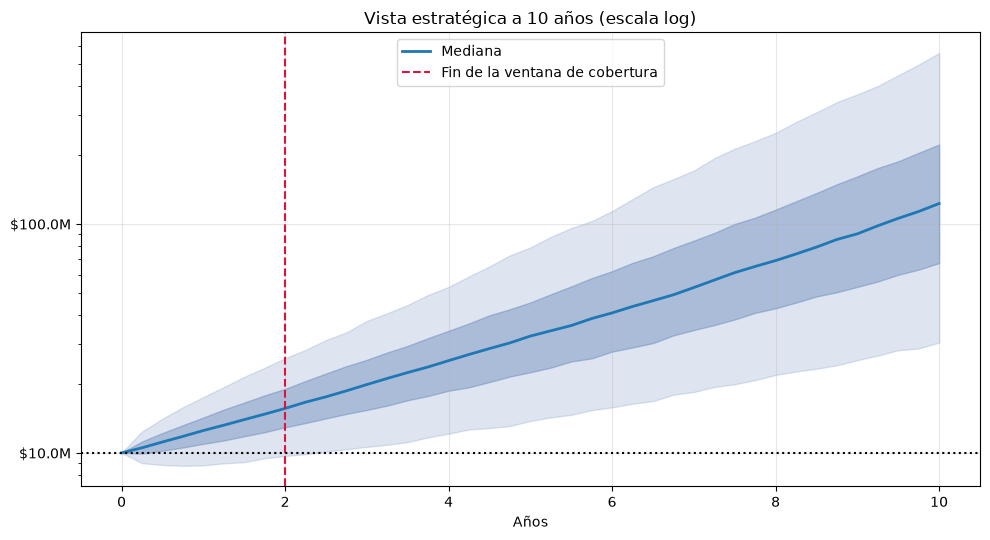

Prob. de valor final < inversión inicial: a 2 años 6.5% | a 10 años 0.2%


In [22]:
idx_10y = np.arange(0, 10 * DIAS_ANIO + 1, PASOS_TRIMESTRE)
S10, D10 = simular_portafolio(N_PATHS_10Y, 10 * DIAS_ANIO, idx_10y, seed=SEED + 1)
port10 = (S10 * acciones).sum(2) + (D10 * acciones).sum(2)
x10 = idx_10y / DIAS_ANIO
fig, ax = plt.subplots(figsize=(10, 5.5))
for lo, hi, al in [(5, 95, 0.18), (25, 75, 0.35)]:
    ax.fill_between(x10, np.percentile(port10, lo, 0), np.percentile(port10, hi, 0), alpha=al, color="#4c72b0")
ax.plot(x10, np.percentile(port10, 50, 0), lw=2, label="Mediana")
ax.axvline(HORIZONTE_ANIOS, color="crimson", ls="--", label="Fin de la ventana de cobertura")
ax.axhline(portafolio_0, color="k", ls=":")
ax.set_yscale("log"); ax.yaxis.set_major_formatter(musd); ax.set_xlabel("Años"); ax.legend(); ax.grid(alpha=0.3)
ax.set_title("Vista estratégica a 10 años (escala log)"); fig.tight_layout(); fig.savefig(OUT / "fig7_vista_10_anios.png", dpi=170); plt.show()
print(f"Prob. de valor final < inversión inicial: a 2 años {(port10[:, 8] < portafolio_0).mean():.1%} | "
      f"a 10 años {(port10[:, -1] < portafolio_0).mean():.1%}")
del S10, D10

> ### 🧠 Bloque II – Cuánto podríamos perder?
> #### **Paso 7:**
>
> En este paso entendemos como es el movimiento de la volatilidad con el modelo GARCH. El mercado no es igual de nervioso o con el mismo sentimiento de incertidumbre todos los días, ya que, después de un día con información de haga mover el mercado drásticamente, vienen días de nervios y la confianza se va recuperando poco a poco, nuestro modelo captura exactamente eso $$h_t = \omega + \alpha \varepsilon^2_{t-1}+\beta h_{t-1}$$
>
> 1. $\omega$ es un nivel base
> 2. $\alpha$ cuánto afecta el susto actual
> 3. $\beta$ cuánto sigo nervioso por los días anteriores
>
> La suma de $\alpha + \beta$ nos dice que tan rápido se olvida el susto o el sentimiento de incertidumbre que nos generó el mercado, es decir, para nuestras acciones cada una tiene un susto/movimiento de riesgo diferente por lo que su disipación al sentimiento también es distinto. 
>
> Usamos 10 años de historia para el modelo, es importante tener un gran recorrido en la historia, porque el modelo, requiere que hayan grandes movimientos estructurales en la economía para capturar correctamente la volatilidad y aprender como se comportan tales acciones durante crisis. No solo se usa lo que es la distribución normal sino también una distribución $t$ porque las caídas extremas pasan más seguido de lo habitual de lo que podemos comprender en la campana de la normal
> 
> En acciones donde se utiliza una distribución normal para modelar es por lo siguiente, y es que la sumatoria del susto actual y lo que me afecta lo que pasó en días anteriores a mi sentimiento es igual a 1, por lo que, modelar a dos años sería un error, ya que, esto nos dice que el susto nunca se olvida y constantemente me está afectando, se usa una distribución normal aunque no captura correctamente o con mayor exactitud este error se deberá tener en cuenta como inversionistas.
>
> #### **Paso 8:**
>
> Acá simulamos el MBG con 10,000 futuros posibles $$\ln S_{t+1} = \ln S_t + \underbrace{\big(\text{crecimineto }- q - \frac{1}{2} h_t \big)}_{\text{tendencia/drift}} + \underbrace{\sqrt{h_t}z_t}_{\text{sorpresa}} $$
>
> El precio de mañana es el precio de hoy, más una tendencia, más un error aleatorio
> 
> 1. Drift es el crecimiento o tendencia histórica
> 2. La sorpresa tiene el tamaño del ruido que genera el modelo GARCH ese día, además que se tuvo en cuenta el error de las tres acciones conectadas por sus correlaciones (si tenemos un día malo ya sea por una notica a nivel general que afecte la economía), la cartera tiende a caer. 
>
> Este ejercicio se realiza día por día durante 504 días hábiles se son los 2 años o el tiempo destinado a nuestra inversión, lo simulamos 10,000 veces y encontramos que la mediana tras dos años el valor de la cartera de aumenta en un 55% depués de haber transcurrido el primer trimestre, como inversionistas tenemos encuenta que estos son escenarios a darse, no es con seguridad que nuestra cartera generará un +55% de ganancia. 
>  
> #### **Paso 9:**
>
> Medimos que tanto perdemos por Value at risk y por expected shortfall. A 2 años el VaR 95 parece pequeño, esto se da porque, suponemos que LLY sigue teniendo en cuenta el mismo ritmo de crecimiento aunque parezca contradictorio, es un punto que como inversionistas lo vemos crítico para corregir y que si lo medimos a que la acción crezca igual que la tasa libre de riesgo, algo más prudente, se estira más la cola alcanzando una pérdida de +3 millones. Como parte de nuestro análisis nuestro riesgo depende muchísimo de creer en el pasado, por lo que es de suma importancia tener el seguro. 
>
> #### **Paso 10:**
>
> Antes de pasar al mercado real, realizamos una "cotización" del seguro de forma teórica. Una put según lo explicado en clase es comprar el derecho sobre vender una acción a un precio fijo strike $K$. Si la acción cae por debajo de $K$, el seguro nos pagará la diferencia. Si sube, no lo usamos y solo perdemos lo que paguemos por la prima. Con los resultados obtenidos observamos que un poco más del 12% de los escenarios paga más de lo que costó, por lo que tenemos que buscar protección más barata en el mercado real.   

---
## **Bloque III – Selección de opciones de mercado y diseño de coberturas**

| Sección | Qué entrega | Puntos |
|---|---|---|
| 3.1 | Vencimiento común entre 12 y 24 meses y diferencias documentadas | 13 |
| 3.2–3.3 | Cadena de opciones exportada, ≥4 strikes por activo con bid-ask relativo, OI, volumen, IV y moneyness | 14 |
| 3.4 | Árbol binomial CRR europeo vs americano, mismos $S_0,K,T,\sigma,r,q$ | 21 |
| 3.5 | Eficiencia de cada strike (reducción de VaR del portafolio por dólar de prima) y regla de selección | 14, 24 |
| 3.6 | Dimensionamiento 85 % y sensibilidad delta | 17 |
| 3.7–3.9 | Estrategias A (protective put), B (collar), C (overlay en el activo dominante) y sus payoffs | 18, 19 |
| 3.10 | Revaloración trimestral, MTM y reglas mantener / ajustar / renovar | 22 |
| 3.11 | VaR cubierto definitivo vs no cubierto | 12 |
| 3.12–3.13 | Asignación del presupuesto (3 criterios) y costo/eficiencia | 23, 24 |

**Convenciones de ejecución (clase 10):** quien **compra** paga el *ask* y quien **vende** recibe el *bid*. Si el mercado está cerrado y el bid/ask viene en cero, se usa el último precio y la fila queda marcada como `cotizacion_viva = False`; conviene correr esta sección con el mercado abierto y guardar la foto en CSV.

In [23]:
VENC_MIN_M, VENC_MAX_M = 12, 24
MONEYNESS_PUT       = [0.80, 0.85, 0.90, 0.95, 1.00]   # candidatos K/S0 (se toma el strike listado más cercano)
MONEYNESS_CALL      = [1.10, 1.20, 1.30, 1.40]
BANDA_ATM           = 0.025                            # |K/S0 - 1| ≤ 2.5 % -> ATM
SPREAD_MAX          = 0.20                             # (Ask - Bid) / Mid máximo ejecutable
OI_MIN              = 10                               # interés abierto mínimo
PERDIDA_MAX_PISO    = 0.20                             # pérdida máxima tolerada por acción cubierta: (S0 - K + prima) / S0
TECHO_MIN_CALL      = 1.20                             # el collar no capa ganancias por debajo de +20 %
OVERLAY             = "bear_put_spread"                # "bear_put_spread" | "covered_call"
MONEYNESS_BPS_CORTA = 0.75                             # put vendida del bear put spread
N_BINOM             = 500
BANDA_ROLL_UP, BANDA_MONETIZAR, T_RENOVAR = 1.25, 0.90, 0.25   # reglas del punto de control trimestral
MODO_CADENA         = "vivo"                           # "vivo" (Yahoo) | "csv" (reproduce la foto guardada)
RUTA_CADENA         = OUT / "cadenas_opciones.csv"

### 3.1 Vencimiento común

In [24]:
meses = lambda f: (pd.Timestamp(f) - F_VAL).days / 30.4375

if MODO_CADENA == "vivo":
    venc_disp = {t: list(yf.Ticker(t).options) for t in TICKERS}
    en_ventana = {t: [v for v in venc_disp[t] if VENC_MIN_M <= meses(v) <= VENC_MAX_M] for t in TICKERS}
    comunes = sorted(set.intersection(*map(set, en_ventana.values())))
    if comunes:
        objetivo = comunes[-1]                         # el más largo común: cubre la mayor parte de los 2 años con un solo contrato
    else:
        objetivo = max([v for vs in en_ventana.values() for v in vs] or [max(v for vs in venc_disp.values() for v in vs)])
    VENC = {t: min(venc_disp[t], key=lambda v: abs((pd.Timestamp(v) - pd.Timestamp(objetivo)).days)) for t in TICKERS}
else:
    _foto = pd.read_csv(RUTA_CADENA)
    VENC = _foto.groupby("ticker")["vencimiento"].first().to_dict(); objetivo = max(VENC.values()); comunes = []
    venc_disp = en_ventana = {t: [VENC[t]] for t in TICKERS}

T_OPT = {t: (pd.Timestamp(VENC[t]) - F_VAL).days / 365 for t in TICKERS}
N_EXP = {t: min(int(round(T_OPT[t] * DIAS_ANIO)), N_DIAS_SIM) for t in TICKERS}
tabla_venc = pd.DataFrame({
    "vencimientos_en_ventana": {t: ", ".join(en_ventana[t]) for t in TICKERS},
    "vencimiento_elegido": VENC, "meses": {t: meses(VENC[t]) for t in TICKERS}, "T_años": T_OPT,
    "dif_vs_objetivo_dias": {t: (pd.Timestamp(VENC[t]) - pd.Timestamp(objetivo)).days for t in TICKERS},
    "r_plazo": {t: r_plazo(T_OPT[t]) for t in TICKERS}})
display(tabla_venc)
H_VENC = min(N_EXP.values())      # día simulado en que vence la cobertura (fin de la ventana de cobertura)
print(f"Vencimiento {'común' if comunes else 'más cercano al objetivo'}: {objetivo} | la cobertura cubre {H_VENC / DIAS_ANIO:.2f} "
      f"de los {HORIZONTE_ANIOS} años; el tramo restante exige renovar (ver punto 3.10).")

,vencimientos_en_ventana,vencimiento_elegido,meses,T_años,dif_vs_objetivo_dias,r_plazo
LLY,"2027-12-17, 2028-01-21, 2028-06-16",2028-01-21,15.8686,1.3233,0,0.0457
ORCL,"2027-10-15, 2027-12-17, 2028-01-21, 2028-09-15",2028-01-21,15.8686,1.3233,0,0.0457
GD,2028-01-21,2028-01-21,15.8686,1.3233,0,0.0457


Vencimiento común: 2028-01-21 | la cobertura cubre 1.32 de los 2 años; el tramo restante exige renovar (ver punto 3.10).


### 3.2 Cadena de opciones: descarga, exportación y métricas de liquidez

In [25]:
COLS = ["contractSymbol", "strike", "bid", "ask", "lastPrice", "volume", "openInterest", "impliedVolatility", "lastTradeDate"]

if MODO_CADENA == "vivo":
    partes = []
    for t in TICKERS:
        oc = yf.Ticker(t).option_chain(VENC[t])
        for tipo, df in [("call", oc.calls), ("put", oc.puts)]:
            df = df.reindex(columns=COLS).copy(); df["tipo"], df["ticker"], df["vencimiento"] = tipo, t, VENC[t]
            partes.append(df)
    cadena = pd.concat(partes, ignore_index=True)
    cadena["descarga_utc"] = f"{datetime.now(timezone.utc):%Y-%m-%d %H:%M}"
    cadena["spot_S0"] = cadena["ticker"].map(spot)
    cadena.to_csv(RUTA_CADENA, index=False)
else:
    cadena = pd.read_csv(RUTA_CADENA)

def crr(S0, K, T, sigma, r, q, tipo="put", americana=False, N=N_BINOM):
    # Árbol CRR (clase 12): u = e^{σ√Δt}, d = 1/u, p = (e^{(r-q)Δt} - d)/(u - d)
    dt = T / N; u = np.exp(sigma * np.sqrt(dt)); d = 1 / u
    p = (np.exp((r - q) * dt) - d) / (u - d); disc = np.exp(-r * dt)
    assert 0 < p < 1, "Probabilidad neutral al riesgo fuera de (0,1): reducir Δt"
    j = np.arange(N + 1); V = intrinseco(S0 * u ** (N - j) * d ** j, K, tipo)
    for i in range(N - 1, -1, -1):
        V = disc * (p * V[:-1] + (1 - p) * V[1:])
        if americana:
            j = np.arange(i + 1); V = np.maximum(V, intrinseco(S0 * u ** (i - j) * d ** j, K, tipo))
    return float(V[0])

def iv_americana(precio, S0, K, T, r, q, tipo):
    # Volatilidad que iguala el árbol americano (N=200) al precio medio de mercado
    f = lambda s: crr(S0, K, T, s, r, q, tipo, True, 200) - precio
    try:
        return brentq(f, 0.03, 3.0, xtol=1e-5) if precio > intrinseco(S0, K, tipo) + 1e-6 else np.nan
    except ValueError:
        return np.nan

def clase_moneyness(m, tipo):
    if abs(m - 1) <= BANDA_ATM: return "ATM"
    return ("ITM" if m > 1 else "OTM") if tipo == "put" else ("ITM" if m < 1 else "OTM")

def preparar(c):
    c = c.copy()
    for col in ["bid", "ask", "lastPrice", "volume", "openInterest", "impliedVolatility"]:
        c[col] = pd.to_numeric(c[col], errors="coerce").fillna(0.0)
    c["cotizacion_viva"] = (c["bid"] > 0) & (c["ask"] > 0) & (c["ask"] >= c["bid"])
    c["mid"] = np.where(c["cotizacion_viva"], (c["bid"] + c["ask"]) / 2, c["lastPrice"])
    c["spread_rel"] = np.where(c["cotizacion_viva"], (c["ask"] - c["bid"]) / c["mid"], np.nan)
    c["S0"] = c["ticker"].map(spot); c["moneyness"] = c["strike"] / c["S0"]
    c["T"] = c["ticker"].map(T_OPT); c["r"] = c["T"].map(r_plazo); c["q"] = c["ticker"].map(q_div)
    c["clase"] = [clase_moneyness(m, tp) for m, tp in zip(c["moneyness"], c["tipo"])]
    c["precio_compra"] = np.where(c["cotizacion_viva"], c["ask"], c["mid"])
    c["precio_venta"]  = np.where(c["cotizacion_viva"], c["bid"], c["mid"])
    c["pasa_liquidez"] = c["cotizacion_viva"] & (c["spread_rel"] <= SPREAD_MAX) & (c["openInterest"] >= OI_MIN)
    return c

def candidatos(t, tipo, objetivos):
    sub = cadena[(cadena["ticker"] == t) & (cadena["tipo"] == tipo) & (cadena["mid"] > 0)]
    ks = sorted({sub.loc[(sub["strike"] - m * spot[t]).abs().idxmin(), "strike"] for m in objetivos})
    return sub[sub["strike"].isin(ks)].copy()

cadena = preparar(cadena)
cand_put  = pd.concat([candidatos(t, "put",  MONEYNESS_PUT)  for t in TICKERS], ignore_index=True)
cand_call = pd.concat([candidatos(t, "call", MONEYNESS_CALL) for t in TICKERS], ignore_index=True)
for c in (cand_put, cand_call):
    c["IV_americana"] = [iv_americana(r.mid, r.S0, r.strike, r.T, r.r, r.q, r.tipo) for r in c.itertuples()]
    c["vol_GARCH_LP"] = c["ticker"].map(garch_resumen["vol_LP_anual"]).astype(float)
    iv_yahoo = c["impliedVolatility"].where(c["impliedVolatility"] > 0.03)
    c["sigma_fuente"] = np.select([c["IV_americana"].notna(), iv_yahoo.notna()], ["IV americana (mid)", "IV Yahoo"], "vol. GARCH LP (sin cotización útil)")
    c["sigma"] = c["IV_americana"].fillna(iv_yahoo).fillna(c["vol_GARCH_LP"])
print(f"Filas en la cadena: {len(cadena):,} | cotización viva: {cadena['cotizacion_viva'].mean():.0%} | exportada en {RUTA_CADENA}")
assert cand_put.groupby("ticker").size().min() >= 3, "Menos de 3 strikes candidatos en algún activo"

Filas en la cadena: 404 | cotización viva: 87% | exportada en Laboratorio 1\cadenas_opciones.csv


### 3.3 Comparación de strikes candidatos

,ticker,strike,moneyness,clase,bid,ask,mid,spread_rel,openInterest,volume,impliedVolatility,IV_americana,vol_GARCH_LP,prima_%spot,valor_tiempo,perdida_max_piso,pasa_liquidez,cotizacion_viva
0,LLY,950.0,0.803,OTM,68.85,79.80,74.32,14.7%,251,2,35.5%,38.0%,37.5%,6.74%,74.32,26.5%,True,True
1,LLY,1010.0,0.853,OTM,88.85,100.90,94.88,12.7%,32,5,34.9%,37.8%,37.5%,8.53%,94.88,23.2%,True,True
2,LLY,1070.0,0.904,OTM,0.00,0.00,120.80,nan%,0,2,1.6%,38.0%,37.5%,10.21%,120.80,19.8%,False,False
3,LLY,1120.0,0.946,OTM,132.50,148.85,140.68,11.6%,53,10,34.1%,37.4%,37.5%,12.58%,140.68,17.9%,True,True
4,LLY,1180.0,0.997,ATM,0.00,0.00,152.72,nan%,0,1,0.0%,33.8%,37.5%,12.90%,152.72,13.2%,False,False
5,ORCL,110.0,0.802,OTM,16.30,17.10,16.70,4.8%,"3,254",9,50.7%,54.7%,50.5%,12.47%,16.70,32.2%,True,True
6,ORCL,115.0,0.839,OTM,18.65,19.30,18.98,3.4%,"2,465",2,50.4%,54.8%,50.5%,14.08%,18.98,30.2%,True,True
7,ORCL,125.0,0.912,OTM,23.40,24.10,23.75,2.9%,"3,691",10,50.2%,54.4%,50.5%,17.58%,23.75,26.4%,True,True
8,ORCL,130.0,0.948,OTM,25.95,27.10,26.52,4.3%,"9,966",4,50.5%,54.4%,50.5%,19.77%,26.52,24.9%,True,True
9,ORCL,135.0,0.985,ATM,28.80,29.90,29.35,3.7%,"4,262",16,50.3%,54.5%,50.5%,21.81%,29.35,23.3%,True,True


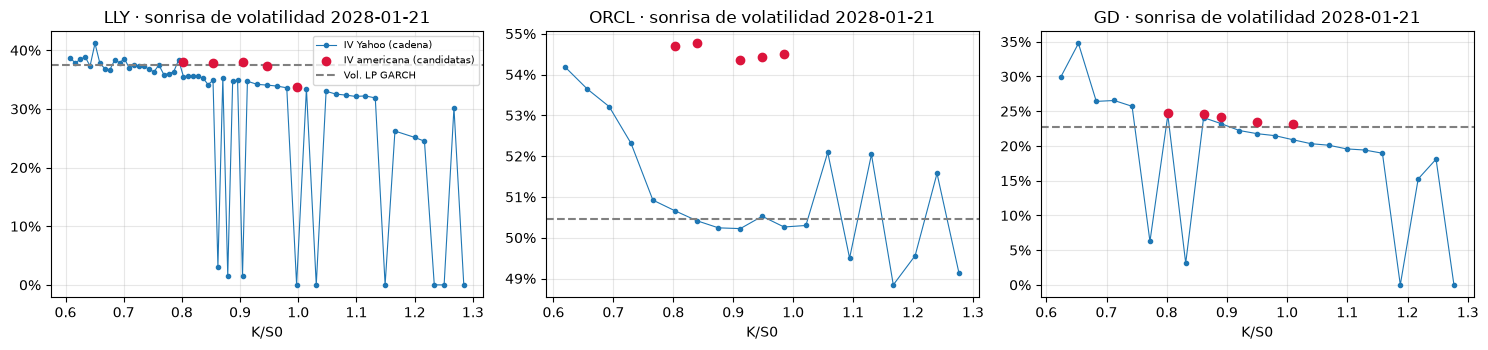

In [26]:
cand_put["perdida_max_piso"] = (cand_put["S0"] - cand_put["strike"] + cand_put["precio_compra"]) / cand_put["S0"]
cand_put["prima_%spot"] = cand_put["precio_compra"] / cand_put["S0"]
cand_put["valor_tiempo"] = cand_put["mid"] - intrinseco(cand_put["S0"], cand_put["strike"], "put")
cols_c = ["ticker", "strike", "moneyness", "clase", "bid", "ask", "mid", "spread_rel", "openInterest", "volume",
          "impliedVolatility", "IV_americana", "vol_GARCH_LP", "prima_%spot", "valor_tiempo", "perdida_max_piso", "pasa_liquidez", "cotizacion_viva"]
fmt_c = {"moneyness": "{:.3f}", "spread_rel": "{:.1%}", "impliedVolatility": "{:.1%}", "IV_americana": "{:.1%}", "vol_GARCH_LP": "{:.1%}",
         "prima_%spot": "{:.2%}", "perdida_max_piso": "{:.1%}", "openInterest": "{:,.0f}", "volume": "{:,.0f}",
         "bid": "{:.2f}", "ask": "{:.2f}", "mid": "{:.2f}", "strike": "{:.1f}", "valor_tiempo": "{:.2f}"}
display(cand_put[cols_c].style.format(fmt_c).set_caption("Puts candidatas"))
cand_put[cols_c].to_csv(OUT / "puts_candidatas.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
for ax, t in zip(axes, TICKERS):
    s = cadena[(cadena["ticker"] == t) & (cadena["tipo"] == "put") & cadena["moneyness"].between(0.6, 1.3) & (cadena["impliedVolatility"] > 0)]
    ax.plot(s["moneyness"], s["impliedVolatility"], ".-", lw=0.8, label="IV Yahoo (cadena)")
    cp = cand_put[cand_put["ticker"] == t]; ax.scatter(cp["moneyness"], cp["IV_americana"], color="crimson", zorder=5, label="IV americana (candidatas)")
    ax.axhline(garch_resumen.loc[t, "vol_LP_anual"], color="gray", ls="--", label="Vol. LP GARCH")
    ax.set_title(f"{t} · sonrisa de volatilidad {VENC[t]}"); ax.yaxis.set_major_formatter(pct); ax.set_xlabel("K/S0"); ax.grid(alpha=0.3)
axes[0].legend(fontsize=7); fig.tight_layout(); fig.savefig(OUT / "fig8_sonrisa_iv.png", dpi=170); plt.show()

**Qué mirar en la tabla.** El *spread* relativo es el costo inmediato de entrar (se compra al *ask* y el contrato vale el *mid*): un 10 % de *spread* es perder 5 % de la prima el primer día. El OI dice si hay contrapartes para rolar o deshacer la posición en los puntos de control. La IV se compara entre strikes (sonrisa: las puts OTM suelen cotizar más caras en volatilidad) y contra la volatilidad GARCH de largo plazo: si la IV está por encima, el mercado cobra una prima de riesgo por la protección. No se elige por menor IV: un strike muy OTM puede tener IV baja y aun así no proteger nada útil.

### 3.4 Valoración binomial europea vs americana
Árbol CRR visto en la clase con dividendo continuo: $u=e^{\sigma\sqrt{\Delta t}}$, $d=1/u$, $p=\frac{e^{(r-q)\Delta t}-d}{u-d}$, y en la americana $f=\max\{\text{intrínseco},\;e^{-r\Delta t}[p f_u+(1-p)f_d]\}$ en cada nodo. Ambas con los mismos $S_0, K, T$, $\sigma$ = IV americana del contrato, $r$ = `r_plazo(T)` y $q$. Black-Scholes se reporta como control de convergencia del árbol europeo.

In [27]:
def valorar(df):
    out = df[["ticker", "tipo", "strike", "clase", "mid", "sigma", "T", "r", "q", "S0"]].copy()
    out["BS_europea"]      = [bs_precio(r.S0, r.strike, r.T, r.sigma, r.r, r.q, r.tipo) for r in out.itertuples()]
    out["CRR_europea"]     = [crr(r.S0, r.strike, r.T, r.sigma, r.r, r.q, r.tipo, False) for r in out.itertuples()]
    out["CRR_americana"]   = [crr(r.S0, r.strike, r.T, r.sigma, r.r, r.q, r.tipo, True) for r in out.itertuples()]
    out["prima_ej_anticipado"]  = out["CRR_americana"] - out["CRR_europea"]
    out["prima_ej_%_americana"] = out["prima_ej_anticipado"] / out["CRR_americana"]
    out["error_CRR_vs_BS"]      = out["CRR_europea"] - out["BS_europea"]
    return out

val_opc = valorar(pd.concat([cand_put, cand_call], ignore_index=True).dropna(subset=["sigma"]))
display(val_opc.drop(columns=["S0"]).style.format({**{c: "{:.3f}" for c in ["mid", "BS_europea", "CRR_europea", "CRR_americana",
        "prima_ej_anticipado", "error_CRR_vs_BS"]}, "strike": "{:.1f}", "sigma": "{:.1%}", "r": "{:.2%}", "q": "{:.2%}",
        "T": "{:.2f}", "prima_ej_%_americana": "{:.1%}"}))
resumen_ej = val_opc.groupby(["ticker", "tipo"])["prima_ej_%_americana"].agg(["min", "max"])
display(resumen_ej.style.format("{:.1%}").set_caption("Peso del ejercicio anticipado en el precio americano"))

,ticker,tipo,strike,clase,mid,sigma,T,r,q,BS_europea,CRR_europea,CRR_americana,prima_ej_anticipado,prima_ej_%_americana,error_CRR_vs_BS
0,LLY,put,950.0,OTM,74.325,38.0%,1.32,4.57%,0.56%,71.857,71.917,74.221,2.304,3.1%,0.060
1,LLY,put,1010.0,OTM,94.875,37.8%,1.32,4.57%,0.56%,91.515,91.478,94.666,3.188,3.4%,-0.037
2,LLY,put,1070.0,OTM,120.800,38.0%,1.32,4.57%,0.56%,116.297,116.378,120.688,4.310,3.6%,0.080
3,LLY,put,1120.0,OTM,140.675,37.4%,1.32,4.57%,0.56%,135.290,135.375,140.762,5.388,3.8%,0.085
4,LLY,put,1180.0,ATM,152.720,33.8%,1.32,4.57%,0.56%,145.903,145.867,152.781,6.914,4.5%,-0.036
5,ORCL,put,110.0,OTM,16.700,54.7%,1.32,4.57%,1.45%,16.319,16.314,16.667,0.353,2.1%,-0.005
6,ORCL,put,115.0,OTM,18.975,54.8%,1.32,4.57%,1.45%,18.580,18.577,18.993,0.416,2.2%,-0.003
7,ORCL,put,125.0,OTM,23.750,54.4%,1.32,4.57%,1.45%,23.207,23.218,23.781,0.563,2.4%,0.011
8,ORCL,put,130.0,OTM,26.525,54.4%,1.32,4.57%,1.45%,25.841,25.831,26.484,0.653,2.5%,-0.010
9,ORCL,put,135.0,ATM,29.350,54.5%,1.32,4.57%,1.45%,28.599,28.608,29.352,0.745,2.5%,0.009


**Interpretación.** En las **puts** el ejercicio anticipado vale más cuanto más dentro del dinero y más alta es $r$: con $r\approx4.5\%$ y $q$ pequeño, recibir $K$ hoy e invertirlo puede valer más que esperar, así que la americana cuesta más que la europea. En las **calls** la diferencia es casi nula porque con dividendos bajos nunca conviene ejercer antes (se renunciaría al valor tiempo). Para el portafolio esto significa que modelar las puts listadas como europeas subestima su costo, y que el MTM trimestral con Black-Scholes (sección 3.10) es una aproximación con un sesgo conocido y acotado por esta tabla.

### 3.5 Eficiencia de cada strike y regla de selección de la put
Para cada put candidata se simula el portafolio con **solo ese activo cubierto** (85 %) hasta el vencimiento y se mide
$$\text{Eficiencia}_{99} = \frac{\text{VaR}_{99}^{\text{sin}} - \text{VaR}_{99}^{\text{con}}}{\text{prima pagada (ask)}}$$
es decir, cuántos dólares de pérdida extrema del **portafolio** elimina cada dólar de prima. Regla: entre los strikes que pasan liquidez y cuya pérdida máxima por acción $(S_0-K+\text{prima})/S_0$ no supera 20 %, se elige el de mayor eficiencia; si ninguno pasa liquidez, se relaja ese filtro y se deja marcado.

In [28]:
def valor_pierna(k, K, T, sigma, tipo, idx, n_exp):
    # MTM por acción en los días idx; tras el vencimiento se conserva el payoff como caja
    out = np.empty((N_PATHS, len(idx)))
    S_exp = S_all[:, n_exp, k]
    for j, d in enumerate(idx):
        if d >= n_exp:
            out[:, j] = intrinseco(S_exp, K, tipo)
        else:
            T_rem = T - d / DIAS_ANIO
            out[:, j] = bs_precio(S_all[:, d, k], K, T_rem, sigma, r_plazo(T_rem), float(q_div.iloc[k]), tipo)
    return out

pnl_venc_nc = valor_nc[:, H_VENC] - portafolio_0
m_nc_venc = metricas_riesgo(pnl_venc_nc)
efs = []
for r_ in cand_put.dropna(subset=["sigma"]).itertuples():
    k = TICKERS.index(r_.ticker); n_c = contratos_85[k] * TAM_CONTRATO
    v = valor_pierna(k, r_.strike, r_.T, r_.sigma, "put", [H_VENC], N_EXP[r_.ticker])[:, 0]
    costo = n_c * r_.precio_compra
    m = metricas_riesgo(pnl_venc_nc + n_c * v - costo)
    efs.append({"idx": r_.Index, "costo_85%": costo, "VaR99_con": m["VaR99"], "ES99_con": m["ES99"],
                "eficiencia_VaR99": (m_nc_venc["VaR99"] - m["VaR99"]) / costo,
                "eficiencia_ES99": (m_nc_venc["ES99"] - m["ES99"]) / costo})
cand_put = cand_put.join(pd.DataFrame(efs).set_index("idx"))

sel_put = {}
for t in TICKERS:
    c = cand_put[(cand_put["ticker"] == t) & cand_put["sigma"].notna() & (cand_put["moneyness"] <= 1 + BANDA_ATM)]
    ok = c[c["pasa_liquidez"] & (c["perdida_max_piso"] <= PERDIDA_MAX_PISO)]
    relajado = ok.empty
    if relajado:
        ok = c[c["perdida_max_piso"] <= PERDIDA_MAX_PISO]
        ok = ok if not ok.empty else c
    fila = ok.loc[ok["eficiencia_VaR99"].idxmax()]
    sel_put[t] = fila.to_dict() | {"liquidez_relajada": relajado}

print(f"Horizonte de evaluación: vencimiento de la cobertura (día {H_VENC}) | VaR99 sin cobertura ${m_nc_venc['VaR99']:,.0f}")
display(cand_put[["ticker", "strike", "moneyness", "clase", "precio_compra", "perdida_max_piso", "pasa_liquidez", "costo_85%",
                  "VaR99_con", "ES99_con", "eficiencia_VaR99", "eficiencia_ES99"]]
        .style.format({"moneyness": "{:.3f}", "precio_compra": "{:.2f}", "perdida_max_piso": "{:.1%}", "costo_85%": "${:,.0f}",
                       "VaR99_con": "${:,.0f}", "ES99_con": "${:,.0f}", "eficiencia_VaR99": "{:.2f}", "eficiencia_ES99": "{:.2f}"}))
tabla_sel = pd.DataFrame(sel_put).T[["strike", "moneyness", "clase", "precio_compra", "spread_rel", "openInterest",
                                      "sigma", "perdida_max_piso", "eficiencia_VaR99", "liquidez_relajada"]]
display(tabla_sel.style.format({"strike": "{:.1f}", "moneyness": "{:.3f}", "precio_compra": "{:.2f}", "spread_rel": "{:.1%}",
                                "openInterest": "{:,.0f}", "sigma": "{:.1%}", "perdida_max_piso": "{:.1%}", "eficiencia_VaR99": "{:.2f}"})
        .set_caption("Put seleccionada por activo"))

Horizonte de evaluación: vencimiento de la cobertura (día 333) | VaR99 sin cobertura $2,420,960


,ticker,strike,moneyness,clase,precio_compra,perdida_max_piso,pasa_liquidez,costo_85%,VaR99_con,ES99_con,eficiencia_VaR99,eficiencia_ES99
0,LLY,950.000000,0.803,OTM,79.80,26.5%,True,"$191,520","$2,376,641","$2,937,845",0.23,1.41
1,LLY,1010.000000,0.853,OTM,100.90,23.2%,True,"$242,160","$2,327,672","$2,915,007",0.39,1.21
2,LLY,1070.000000,0.904,OTM,120.80,19.8%,False,"$289,920","$2,318,459","$2,880,497",0.35,1.13
3,LLY,1120.000000,0.946,OTM,148.85,17.9%,True,"$357,240","$2,323,074","$2,872,779",0.27,0.94
4,LLY,1180.000000,0.997,ATM,152.72,13.2%,False,"$366,528","$2,251,144","$2,789,554",0.46,1.14
5,ORCL,110.000000,0.802,OTM,17.10,32.2%,True,"$179,550","$2,373,235","$3,035,818",0.27,0.95
6,ORCL,115.000000,0.839,OTM,19.30,30.2%,True,"$202,650","$2,359,242","$3,021,683",0.30,0.91
7,ORCL,125.000000,0.912,OTM,24.10,26.4%,True,"$253,050","$2,323,685","$2,990,262",0.38,0.86
8,ORCL,130.000000,0.948,OTM,27.10,24.9%,True,"$284,550","$2,313,424","$2,979,666",0.38,0.80
9,ORCL,135.000000,0.985,ATM,29.90,23.3%,True,"$313,950","$2,308,962","$2,965,394",0.36,0.77


,strike,moneyness,clase,precio_compra,spread_rel,openInterest,sigma,perdida_max_piso,eficiencia_VaR99,liquidez_relajada
LLY,1120.0,0.946,OTM,148.85,11.6%,53,37.4%,17.9%,0.27,False
ORCL,125.0,0.912,OTM,24.10,2.9%,"3,691",54.4%,26.4%,0.38,True
GD,320.0,0.950,OTM,25.00,19.8%,34,23.4%,12.4%,0.92,False


### 3.6 Dimensionamiento del 85 % y sensibilidad delta
La cobertura base compra 1 put por cada acción cubierta (1:1). Eso fija un **piso** en $K$ para esas acciones al vencimiento, pero **no** neutraliza hoy la sensibilidad del portafolio: una put OTM con $\Delta=-0.3$ solo compensa 30 centavos por cada dólar que cae la acción. Neutralizar el 85 % del delta exigiría $0.85\,N/(|\Delta|\cdot100)$ contratos.

In [29]:
filas = []
for k, t in enumerate(TICKERS):
    s = sel_put[t]; dlt = bs_delta(spot[t], s["strike"], T_OPT[t], s["sigma"], r_plazo(T_OPT[t]), float(q_div[t]), "put")
    n_c = contratos_85[k]
    filas.append({"acciones": int(acciones[k]), "objetivo_85%": COBERTURA * acciones[k], "contratos_1a1": int(n_c),
                  "acciones_cubiertas": int(n_c * TAM_CONTRATO), "cobertura_efectiva": cobertura_efectiva[k],
                  "delta_put": dlt, "delta_residual_%": (acciones[k] + n_c * TAM_CONTRATO * dlt) / acciones[k],
                  "contratos_delta_neutral_85%": int(np.ceil(COBERTURA * acciones[k] / (abs(dlt) * TAM_CONTRATO))),
                  "piso_acciones_cubiertas_USD": n_c * TAM_CONTRATO * s["strike"]})
dimension = pd.DataFrame(filas, index=TICKERS)
display(dimension.style.format({"objetivo_85%": "{:,.0f}", "cobertura_efectiva": "{:.2%}", "delta_put": "{:.3f}",
                                "delta_residual_%": "{:.1%}", "piso_acciones_cubiertas_USD": "${:,.0f}"}))

,acciones,objetivo_85%,contratos_1a1,acciones_cubiertas,cobertura_efectiva,delta_put,delta_residual_%,contratos_delta_neutral_85%,piso_acciones_cubiertas_USD
LLY,2799,"2,379",24,2400,85.74%,-0.318,72.7%,75,"$2,688,000"
ORCL,12304,"10,458",105,10500,85.34%,-0.294,74.9%,357,"$1,312,500"
GD,14849,"12,622",126,12600,84.85%,-0.315,73.2%,401,"$4,032,000"


### 3.7 Estrategias A, B y C
- **A – Protective put:** larga en la put seleccionada sobre `contratos_85` de cada activo.

- **B – Collar:** la misma put + venta de una call OTM sobre la misma cantidad. Regla de la call: el strike líquido más bajo con $K_c/S_0 \ge 1.20$ (máxima financiación sin capar ganancias por debajo de +20 %).

- **C – Overlay en el activo dominante (`ACTIVO_DOMINANTE`):** sobre la estrategia A se añade, solo en ese activo, la venta de una put de strike ≈75 % del spot, formando un **bear put spread**. Tesis: el activo que más riesgo aporta es también el más caro de proteger; el *spread* abarata esa protección renunciando a cubrir caídas superiores a ≈25 %, que es el tramo que el portafolio diversificado y el horizonte de 2 años toleran mejor. Con `OVERLAY = "covered_call"` se evalúa la alternativa (vender una call y monetizar prima si se espera lateralidad).

- Straddles, strangles, butterflies o box spreads no se usan como cobertura principal: apuestan a volatilidad o a rango, o son arbitraje de tasas, no protección direccional de una cartera larga.

In [30]:
sel_call = {}
for t in TICKERS:
    c = cand_call[(cand_call["ticker"] == t) & cand_call["sigma"].notna()]
    ok = c[c["pasa_liquidez"] & (c["moneyness"] >= TECHO_MIN_CALL - 1e-9)]
    if ok.empty:
        ok = c[c["moneyness"] >= TECHO_MIN_CALL - 1e-9]
    ok = ok if not ok.empty else c
    sel_call[t] = ok.loc[ok["strike"].idxmin()].to_dict()

display(cand_call[["ticker", "strike", "moneyness", "clase", "bid", "ask", "spread_rel", "openInterest", "volume", "IV_americana", "pasa_liquidez"]]
        .style.format({"moneyness": "{:.3f}", "spread_rel": "{:.1%}", "IV_americana": "{:.1%}", "openInterest": "{:,.0f}"}).set_caption("Calls candidatas"))

def pierna(t, tipo, K, precio, sigma, signo):
    return {"t": t, "k": TICKERS.index(t), "tipo": tipo, "K": float(K), "precio": float(precio), "sigma": float(sigma),
            "T": T_OPT[t], "n_exp": N_EXP[t], "n": contratos_85[TICKERS.index(t)] * TAM_CONTRATO, "signo": signo}

legs_A = [pierna(t, "put", sel_put[t]["strike"], sel_put[t]["precio_compra"], sel_put[t]["sigma"], +1) for t in TICKERS]
legs_B = legs_A + [pierna(t, "call", sel_call[t]["strike"], sel_call[t]["precio_venta"], sel_call[t]["sigma"], -1) for t in TICKERS]

t_dom = ACTIVO_DOMINANTE
if OVERLAY == "bear_put_spread":
    c = cadena[(cadena["ticker"] == t_dom) & (cadena["tipo"] == "put") & (cadena["strike"] < sel_put[t_dom]["strike"]) & (cadena["mid"] > 0)].copy()
    c = c.assign(dist=(c["moneyness"] - MONEYNESS_BPS_CORTA).abs()).sort_values(["pasa_liquidez", "dist"], ascending=[False, True])
    corta = c.iloc[0]
    sig_c = iv_americana(corta["mid"], corta["S0"], corta["strike"], corta["T"], corta["r"], corta["q"], "put")
    sig_c = sig_c if np.isfinite(sig_c) else corta["impliedVolatility"]
    legs_C = legs_A + [pierna(t_dom, "put", corta["strike"], corta["precio_venta"], sig_c, -1)]
    desc_C = f"Bear put spread en {t_dom}: +put {sel_put[t_dom]['strike']:.0f} / −put {corta['strike']:.0f}"
else:
    legs_C = legs_A + [pierna(t_dom, "call", sel_call[t_dom]["strike"], sel_call[t_dom]["precio_venta"], sel_call[t_dom]["sigma"], -1)]
    desc_C = f"Covered call en {t_dom}: −call {sel_call[t_dom]['strike']:.0f} sobre A"

ESTRATEGIAS = {"A · Protective put": legs_A, "B · Collar": legs_B, f"C · {OVERLAY}": legs_C}
prima_neta = {e: sum(l["signo"] * l["n"] * l["precio"] for l in legs) for e, legs in ESTRATEGIAS.items()}

filas = []
for t in TICKERS:
    kp, kc = sel_put[t], sel_call[t]; n_c = contratos_85[TICKERS.index(t)] * TAM_CONTRATO
    filas.append({"K_put": kp["strike"], "K_call": kc["strike"], "prima_put_USD": n_c * kp["precio_compra"],
                  "prima_call_USD": n_c * kc["precio_venta"], "neto_collar_USD": n_c * (kp["precio_compra"] - kc["precio_venta"]),
                  "financiación_collar": kc["precio_venta"] / kp["precio_compra"],
                  "piso_%": kp["strike"] / spot[t] - kp["precio_compra"] / spot[t], "techo_collar_%": kc["strike"] / spot[t] - 1})
display(pd.DataFrame(filas, index=TICKERS).style.format({"K_put": "{:.1f}", "K_call": "{:.1f}", "prima_put_USD": "${:,.0f}",
        "prima_call_USD": "${:,.0f}", "neto_collar_USD": "${:,.0f}", "financiación_collar": "{:.0%}", "piso_%": "{:+.1%}", "techo_collar_%": "{:+.1%}"}))
print(desc_C)
print(pd.Series(prima_neta).map(lambda v: f"${v:,.0f} ({v / portafolio_0:.2%} del portafolio)").to_string())

,ticker,strike,moneyness,clase,bid,ask,spread_rel,openInterest,volume,IV_americana,pasa_liquidez
0,LLY,1300.000000,1.098,OTM,180.000000,198.000000,9.5%,747,1.000000,38.9%,True
1,LLY,1420.000000,1.200,OTM,145.400000,152.700000,4.9%,52,2.000000,38.7%,True
2,LLY,1540.000000,1.301,OTM,108.000000,119.400000,10.0%,14,1.000000,37.8%,True
3,LLY,1660.000000,1.403,OTM,82.200000,96.500000,16.0%,209,1.000000,37.8%,True
4,ORCL,150.000000,1.094,OTM,32.300000,33.300000,3.0%,"2,968",55.000000,58.1%,True
5,ORCL,165.000000,1.204,OTM,26.350000,29.950000,12.8%,463,8.000000,57.8%,True
6,ORCL,180.000000,1.313,OTM,24.000000,24.400000,1.7%,"2,236",37.000000,57.5%,True
7,ORCL,190.000000,1.386,OTM,21.350000,23.250000,8.5%,"1,048",4.000000,58.0%,True
8,GD,370.000000,1.099,OTM,26.100000,31.000000,17.2%,148,1.000000,24.2%,True
9,GD,400.000000,1.188,OTM,16.000000,21.000000,27.0%,105,2.000000,23.4%,False


,K_put,K_call,prima_put_USD,prima_call_USD,neto_collar_USD,financiación_collar,piso_%,techo_collar_%
LLY,1120.0,1540.0,"$357,240","$259,200","$98,040",73%,+82.1%,+30.1%
ORCL,125.0,165.0,"$253,050","$276,675","$-23,625",109%,+73.6%,+20.4%
GD,320.0,440.0,"$315,000","$112,140","$202,860",36%,+87.6%,+30.7%


Bear put spread en LLY: +put 1120 / −put 890
A · Protective put     $925,290 (9.25% del portafolio)
B · Collar             $277,275 (2.77% del portafolio)
C · bear_put_spread    $800,370 (8.00% del portafolio)


### 3.8 Payoff / P&L al vencimiento por acción cubierta (gráfico obligatorio)

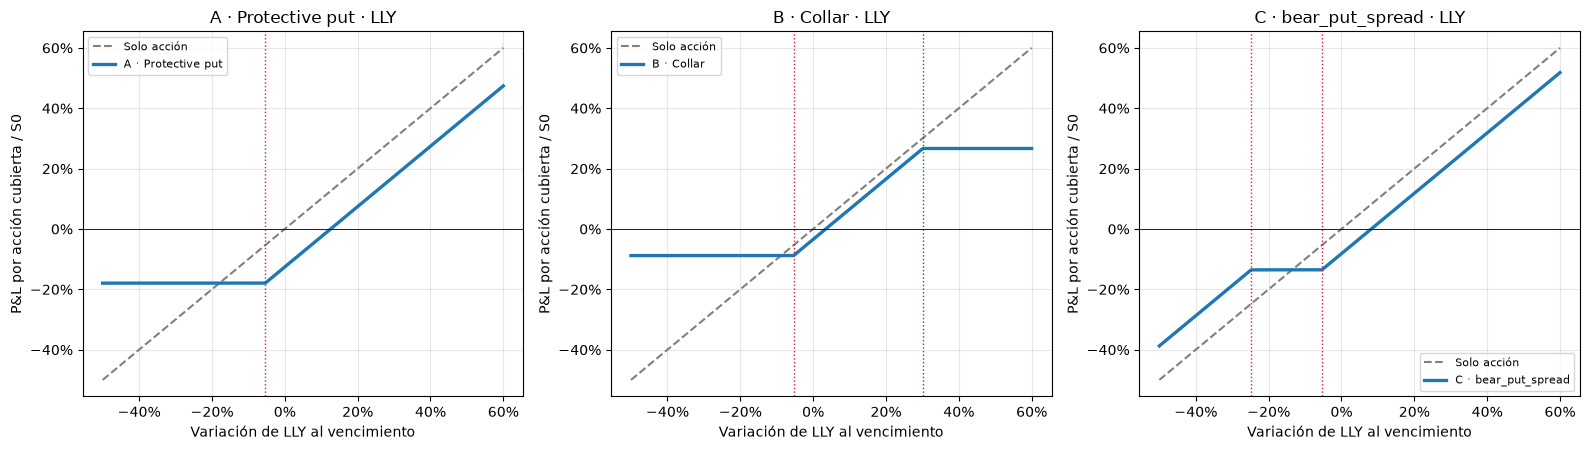

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
for ax, (nombre, legs) in zip(axes, ESTRATEGIAS.items()):
    t = t_dom if nombre.startswith("C") else ACTIVO_DOMINANTE
    S0 = spot[t]; ST = np.linspace(0.5 * S0, 1.6 * S0, 400)
    pyg = ST - S0
    for l in legs:
        if l["t"] == t:
            pyg = pyg + l["signo"] * (intrinseco(ST, l["K"], l["tipo"]) - l["precio"])
    ax.plot(ST / S0 - 1, (ST - S0) / S0, "--", color="gray", label="Solo acción")
    ax.plot(ST / S0 - 1, pyg / S0, lw=2.4, label=nombre)
    for l in legs:
        if l["t"] == t:
            ax.axvline(l["K"] / S0 - 1, color="crimson" if l["tipo"] == "put" else "green", ls=":", lw=1)
    ax.axhline(0, color="k", lw=0.6); ax.xaxis.set_major_formatter(pct); ax.yaxis.set_major_formatter(pct)
    ax.set_xlabel(f"Variación de {t} al vencimiento"); ax.set_ylabel("P&L por acción cubierta / S0")
    ax.set_title(f"{nombre} · {t}"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig(OUT / "fig9_payoffs_estrategias.png", dpi=170); plt.show()

### 3.9 Motor de valoración sobre las 10.000 trayectorias
Cada pierna se revalora en cada día pedido: antes del vencimiento con Black-Scholes a la IV del contrato (supuesto de *sticky strike*), $r$ del plazo remanente y $q$; al vencimiento queda su payoff como caja. $P\&L_t = V^{acc}_t + V^{opc}_t - (V_0 + \text{prima neta})$: comprar al *ask* y valorar al *mid* hace que el *spread* aparezca como pérdida desde el día uno, como en la realidad.

In [32]:
IDX_EVAL = sorted(set(IDX_TRIM.tolist()) | {H_VENC})

def mtm_estrategia(legs, idx=IDX_EVAL):
    V = np.zeros((N_PATHS, len(idx)))
    for l in legs:
        V += l["signo"] * l["n"] * valor_pierna(l["k"], l["K"], l["T"], l["sigma"], l["tipo"], idx, l["n_exp"])
    return V

MTM = {e: mtm_estrategia(legs) for e, legs in ESTRATEGIAS.items()}
V_nc_eval = valor_nc[:, IDX_EVAL]
PNL = {"Sin cobertura": V_nc_eval - portafolio_0}
PNL.update({e: V_nc_eval + MTM[e] - portafolio_0 - prima_neta[e] for e in ESTRATEGIAS})
col = {d: j for j, d in enumerate(IDX_EVAL)}

### 3.10 Puntos de control trimestrales: MTM y decisión
En cada cierre trimestral se revalora la put de cada activo y se aplica una regla explícita:

- **RENOVAR** si quedan ≤ 3 meses al vencimiento (rolar al siguiente vencimiento largo antes de que el *theta* se acelere) o si ya venció dentro de la ventana de 2 años;

- **AJUSTAR (roll-up)** si $S/K \ge 1.25$: la put quedó tan lejos que su delta es mínimo y ya no protege lo ganado; se vende y se compra una de strike mayor;

- **MONETIZAR** si $S/K \le 0.90$: la put está en el dinero; se puede realizar la ganancia y recomprar un strike menor, liberando caja sin quedar descubierto;

- **MANTENER** en otro caso.

La tabla reporta en qué porcentaje de los 10.000 escenarios se activa cada decisión.

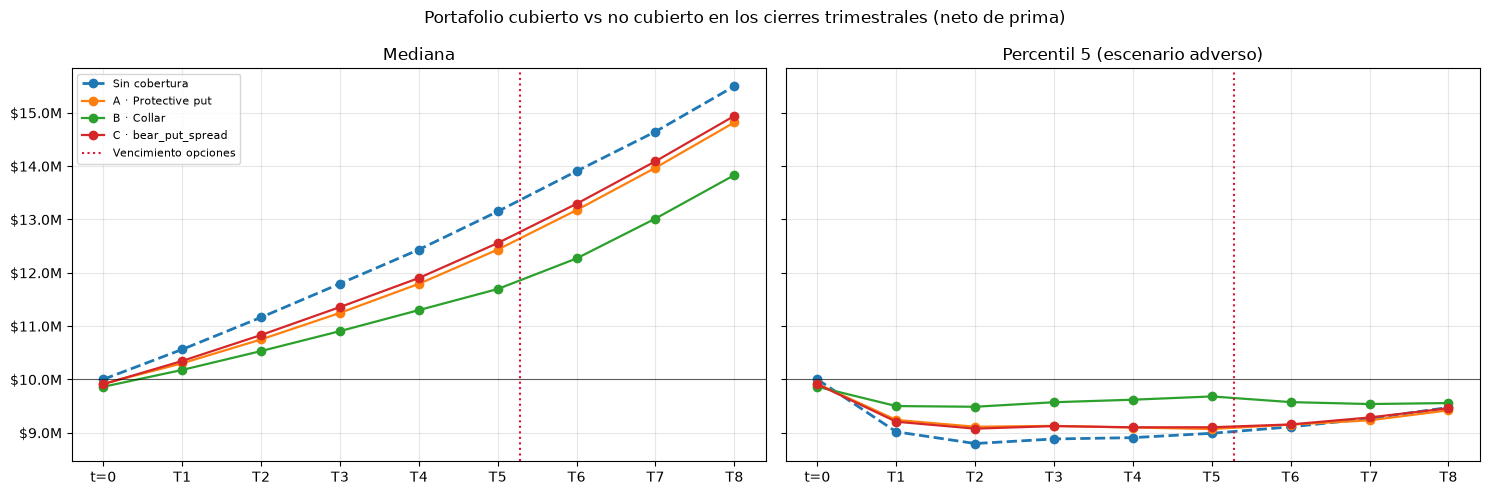

In [33]:
def decision(S, K, T_rem, vencida):
    return np.select([vencida | (T_rem <= T_RENOVAR), S / K >= BANDA_ROLL_UP, S / K <= BANDA_MONETIZAR],
                     ["RENOVAR", "AJUSTAR (roll-up)", "MONETIZAR"], "MANTENER")

reg = []
for i, d in enumerate(IDX_TRIM[1:], start=1):
    for l in legs_A:
        S = S_all[:, d, l["k"]]; T_rem = l["T"] - d / DIAS_ANIO
        dec = decision(S, l["K"], T_rem, np.full(N_PATHS, d >= l["n_exp"]))
        reg.append({"cierre": f"T{i}", "activo": l["t"], **{k_: (dec == k_).mean() for k_ in ["MANTENER", "AJUSTAR (roll-up)", "MONETIZAR", "RENOVAR"]},
                    "MTM_put_mediano_USD": np.median(l["n"] * valor_pierna(l["k"], l["K"], l["T"], l["sigma"], "put", [d], l["n_exp"])[:, 0])})
decisiones = pd.DataFrame(reg).set_index(["cierre", "activo"])
display(decisiones.style.format({**{c: "{:.0%}" for c in ["MANTENER", "AJUSTAR (roll-up)", "MONETIZAR", "RENOVAR"]}, "MTM_put_mediano_USD": "${:,.0f}"}))

val_trim = pd.DataFrame({e: np.percentile(p[:, [col[d] for d in IDX_TRIM]] + portafolio_0, 50, axis=0) for e, p in PNL.items()}, index=ETQ_TRIM)
p5_trim  = pd.DataFrame({e: np.percentile(p[:, [col[d] for d in IDX_TRIM]] + portafolio_0, 5, axis=0) for e, p in PNL.items()}, index=ETQ_TRIM)
display(pd.concat({"Mediana": val_trim, "P5": p5_trim}, axis=1).style.format("${:,.0f}").set_caption("Valor neto de prima en cada cierre trimestral"))

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
x = np.arange(len(IDX_TRIM))
for ax, tabla, titulo in [(axes[0], val_trim, "Mediana"), (axes[1], p5_trim, "Percentil 5 (escenario adverso)")]:
    for e in tabla:
        ax.plot(x, tabla[e], marker="o", lw=2 if e == "Sin cobertura" else 1.6, ls="--" if e == "Sin cobertura" else "-", label=e)
    ax.axhline(portafolio_0, color="k", lw=0.8, alpha=0.6)
    ax.axvline(H_VENC / PASOS_TRIMESTRE, color="crimson", ls=":", label="Vencimiento opciones")
    ax.set_xticks(x); ax.set_xticklabels(ETQ_TRIM); ax.yaxis.set_major_formatter(musd); ax.set_title(titulo); ax.grid(alpha=0.3)
axes[0].legend(fontsize=8); fig.suptitle("Portafolio cubierto vs no cubierto en los cierres trimestrales (neto de prima)")
fig.tight_layout(); fig.savefig(OUT / "fig10_cubierto_vs_no_trimestral.png", dpi=170); plt.show()

### 3.11 VaR del portafolio cubierto con contratos reales
Además de la reducción de VaR/ES se reportan dos eficiencias: por dólar de **prima neta** (lo que pide el enunciado) y por dólar de **costo económico** = caída del P&L esperado frente a no cubrir (prima + *spread* + alza cedida por las calls vendidas). La segunda es la que usaría un gestor: un collar puede costar casi cero en prima y, aun así, ser la cobertura más cara si el retorno esperado del activo es alto.

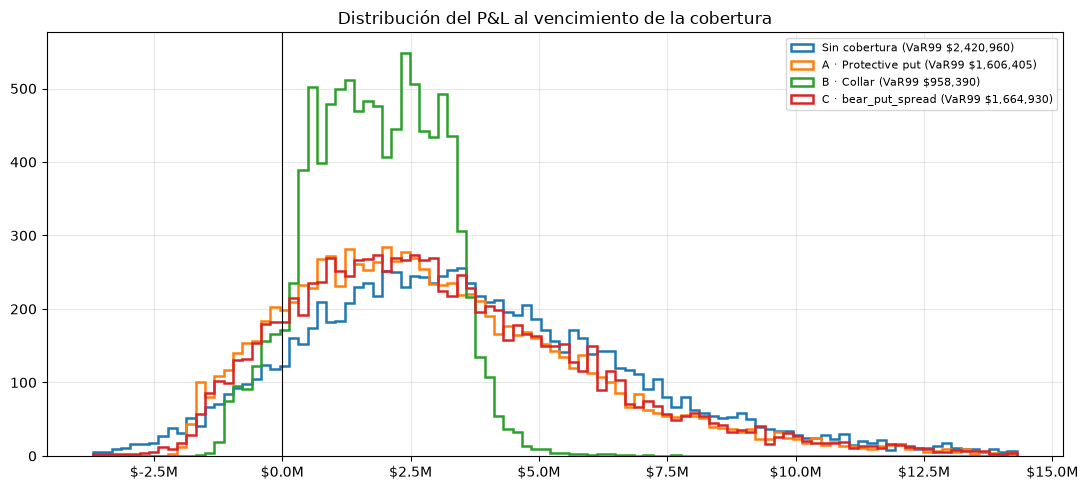

In [34]:
horizontes = {"T1": IDX_TRIM[1], f"Venc. cobertura ({H_VENC / DIAS_ANIO:.2f} a)": H_VENC, f"T{N_TRIMESTRES}": IDX_TRIM[-1]}
filas = []
for h, d in horizontes.items():
    base = metricas_riesgo(PNL["Sin cobertura"][:, col[d]])
    for e, p in PNL.items():
        m = metricas_riesgo(p[:, col[d]]); costo = prima_neta.get(e, 0.0)
        filas.append({"horizonte": h, "estrategia": e, "prima_neta": costo, **m,
                      "Δ VaR95": 1 - m["VaR95"] / base["VaR95"], "Δ VaR99": 1 - m["VaR99"] / base["VaR99"], "Δ ES99": 1 - m["ES99"] / base["ES99"],
                      "ΔVaR99 por $ prima": (base["VaR99"] - m["VaR99"]) / costo if abs(costo) > 1 else np.nan,
                      "costo_economico": base["P&L_medio"] - m["P&L_medio"],
                      "ΔVaR99 por $ costo económico": (base["VaR99"] - m["VaR99"]) / (base["P&L_medio"] - m["P&L_medio"])
                                                      if base["P&L_medio"] - m["P&L_medio"] > 1 else np.nan})
tabla_var_cub = pd.DataFrame(filas).set_index(["horizonte", "estrategia"])
display(tabla_var_cub.drop(columns=["ES95"]).style.format("${:,.0f}", subset=["prima_neta", "VaR95", "VaR99", "ES99", "P&L_medio", "costo_economico"])
        .format("{:+.1%}", subset=["Δ VaR95", "Δ VaR99", "Δ ES99"]).format("{:.2f}", subset=["ΔVaR99 por $ prima", "ΔVaR99 por $ costo económico"]))

d = H_VENC
fig, ax = plt.subplots(figsize=(11, 5))
lo, hi = np.percentile(PNL["Sin cobertura"][:, col[d]], [0.2, 99])
for e, p in PNL.items():
    ax.hist(p[:, col[d]], bins=np.linspace(lo, hi, 100), histtype="step", lw=1.8, label=f"{e} (VaR99 ${metricas_riesgo(p[:, col[d]])['VaR99']:,.0f})")
ax.xaxis.set_major_formatter(musd); ax.axvline(0, color="k", lw=0.8); ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax.set_title("Distribución del P&L al vencimiento de la cobertura"); fig.tight_layout(); fig.savefig(OUT / "fig11_pnl_estrategias.png", dpi=170); plt.show()

### 3.12 Cómo repartir el presupuesto de cobertura?
Con el presupuesto $B$ = costo de la estrategia A base, se comparan tres repartos (puts ya seleccionadas; contratos enteros, máximo 100 % de las acciones):
1. **Valor invertido:** $B_i = B\cdot V_i/\sum V$.
2. **Contribución al riesgo:** $B_i = B\cdot\%RC_i$.
3. **Eficiencia:** se llena primero el activo con mayor reducción de VaR99 por dólar (3.5) hasta cubrir 100 % de sus acciones, luego el siguiente.

Si un activo alcanza el 100 % de sus acciones, el sobrante se redistribuye. Cada reparto se evalúa en el portafolio completo al vencimiento y se elige el que, **con el mismo presupuesto**, deja el menor VaR99 (desempate por ES99).

In [35]:
costo_contrato = np.array([sel_put[t]["precio_compra"] * TAM_CONTRATO for t in TICKERS])
max_contratos  = np.floor(acciones / TAM_CONTRATO)
B = float((contratos_85 * costo_contrato).sum())
V_put = np.stack([valor_pierna(l["k"], l["K"], l["T"], l["sigma"], "put", [H_VENC], l["n_exp"])[:, 0] * TAM_CONTRATO for l in legs_A], axis=1)

def evaluar_reparto(nc):
    nc = np.minimum(np.floor(nc), max_contratos); gasto = float((nc * costo_contrato).sum())
    m = metricas_riesgo(pnl_venc_nc + V_put @ nc - gasto)
    return nc, gasto, m

def reparto_pesos(w):
    # Reparte B según w; si un activo llega al 100 % de sus acciones, el sobrante se redistribuye entre los demás
    w, nc, libres, resto = np.asarray(w, float), np.zeros(3), np.ones(3, bool), B
    while resto > costo_contrato[libres].min() if libres.any() else False:
        asig = resto * w * libres / (w * libres).sum()
        nuevo = np.minimum(nc + asig / costo_contrato, max_contratos)
        resto -= ((nuevo - nc) * costo_contrato).sum(); nc = nuevo
        libres = nc < max_contratos - 1e-9
        if (asig / costo_contrato < 1).all():
            break
    return nc

eff = np.array([sel_put[t]["eficiencia_VaR99"] for t in TICKERS])
nc_eff, resto = np.zeros(3), B
for k in np.argsort(-eff):
    nc_eff[k] = min(max_contratos[k], np.floor(resto / costo_contrato[k])); resto -= nc_eff[k] * costo_contrato[k]

repartos = {"Base 85 % uniforme": contratos_85, "Valor invertido": reparto_pesos(invertido / invertido.sum()),
            "Contribución al riesgo": reparto_pesos(riesgo["RC_pct"].values), "Eficiencia (VaR99/$)": nc_eff}
filas = []
for nombre, nc in repartos.items():
    nc, gasto, m = evaluar_reparto(nc)
    filas.append({"criterio": nombre, **{f"cob_{t}": nc[k] * TAM_CONTRATO / acciones[k] for k, t in enumerate(TICKERS)},
                  **{f"USD_{t}": nc[k] * costo_contrato[k] for k, t in enumerate(TICKERS)},
                  "gasto": gasto, "VaR99": m["VaR99"], "ES99": m["ES99"], "ΔVaR99 por $": (m_nc_venc["VaR99"] - m["VaR99"]) / gasto})
tabla_rep = pd.DataFrame(filas).set_index("criterio")
display(tabla_rep.style.format("{:.0%}", subset=[c for c in tabla_rep if c.startswith("cob_")])
        .format("${:,.0f}", subset=[c for c in tabla_rep if c.startswith("USD_")] + ["gasto", "VaR99", "ES99"]).format("{:.2f}", subset=["ΔVaR99 por $"]))
alt = tabla_rep.drop(index="Base 85 % uniforme")
CRITERIO_PRESUPUESTO = alt.sort_values(["VaR99", "ES99"]).index[0]
print(f"Criterio recomendado: {CRITERIO_PRESUPUESTO}: con el mismo presupuesto deja el menor VaR99 "
      f"(${alt.loc[CRITERIO_PRESUPUESTO, 'VaR99']:,.0f} vs ${tabla_rep.loc['Base 85 % uniforme', 'VaR99']:,.0f} de la base).")

,cob_LLY,cob_ORCL,cob_GD,USD_LLY,USD_ORCL,USD_GD,gasto,VaR99,ES99,ΔVaR99 por $
criterio,,,,,,,,,,
Base 85 % uniforme,86%,85%,85%,"$357,240","$253,050","$315,000","$925,290","$1,606,405","$1,741,714",0.88
Valor invertido,86%,63%,100%,"$357,240","$185,570","$370,000","$912,810","$1,593,263","$1,744,313",0.91
Contribución al riesgo,89%,64%,96%,"$372,125","$190,390","$357,500","$920,015","$1,600,480","$1,735,103",0.89
Eficiencia (VaR99/$),61%,100%,100%,"$253,045","$296,430","$370,000","$919,475","$1,559,099","$1,817,265",0.94


Criterio recomendado: Eficiencia (VaR99/$): con el mismo presupuesto deja el menor VaR99 ($1,559,099 vs $1,606,405 de la base).


### 3.13 Costo y eficiencia de la cobertura

In [39]:
costo_activo = pd.DataFrame({e: {t: sum(l["signo"] * l["n"] * l["precio"] for l in legs if l["t"] == t) for t in TICKERS}
                             for e, legs in ESTRATEGIAS.items()})
costo_activo.loc["TOTAL"] = costo_activo.sum()
costo_pct = costo_activo / portafolio_0
display(pd.concat({"USD": costo_activo, "% del portafolio": costo_pct}, axis=1)
        .style.format("${:,.0f}", subset=pd.IndexSlice[:, "USD"]).format("{:.2%}", subset=pd.IndexSlice[:, "% del portafolio"]))

hv = list(horizontes)[1]
efi = tabla_var_cub.loc[hv].drop(index="Sin cobertura")[["prima_neta", "costo_economico", "VaR99", "ES99", "Δ VaR99", "Δ ES99",
                                                         "ΔVaR99 por $ prima", "ΔVaR99 por $ costo económico"]]
efi["costo_oportunidad_prima"] = efi["prima_neta"] * (np.exp(r_plazo(H_VENC / DIAS_ANIO) * H_VENC / DIAS_ANIO) - 1)
efi["pago_esperado_neto_opciones"] = efi["prima_neta"] - efi["costo_economico"]   # < 0: las calls vendidas entregan alza
display(efi.style.format("${:,.0f}", subset=["prima_neta", "costo_economico", "pago_esperado_neto_opciones", "VaR99", "ES99", "costo_oportunidad_prima"])
        .format("{:+.1%}", subset=["Δ VaR99", "Δ ES99"]).format("{:.2f}", subset=["ΔVaR99 por $ prima", "ΔVaR99 por $ costo económico"])
        .set_caption(f"Eficiencia al {hv}"))
ACTIVO_MAYOR_PRESUPUESTO = costo_activo.drop(index="TOTAL")["A · Protective put"].idxmax()
print(f"Activo con mayor presupuesto de protección (A): {ACTIVO_MAYOR_PRESUPUESTO} "
      f"({costo_activo.loc[ACTIVO_MAYOR_PRESUPUESTO, 'A · Protective put'] / costo_activo.loc['TOTAL', 'A · Protective put']:.0%} de la prima total)")

,prima_neta,costo_economico,VaR99,ES99,Δ VaR99,Δ ES99,ΔVaR99 por $ prima,ΔVaR99 por $ costo económico,costo_oportunidad_prima,pago_esperado_neto_opciones
estrategia,,,,,,,,,,
A · Protective put,"$925,290","$608,785","$1,606,405","$1,741,714",+33.6%,+45.7%,0.88,1.34,"$57,638","$316,505"
B · Collar,"$277,275","$1,956,916","$958,390","$1,093,699",+60.4%,+65.9%,5.27,0.75,"$17,272","$-1,679,641"
C · bear_put_spread,"$800,370","$503,691","$1,664,930","$2,218,219",+31.2%,+30.8%,0.94,1.50,"$49,856","$296,679"


Activo con mayor presupuesto de protección (A): LLY (39% de la prima total)


> ### 🧠 Bloque III – Qué seguro compramos en el mercado?
> #### **Paso 11:**
> 
> En este paso elegimos cuando vence el seguro, buscamos vencimientos iguales de las tres acciones de nuestra cartera, entre 12 y 24 meses, se eligión una cobertura de 16 meses con vencimiento el 21 de enero del 2028, lo elegimos ya que es el de mayor cobertura que ofrecen las tres acciones, por lo que con un solo contrato cubro el mayor tiempo en el horizonte de la inversión establecida; nos quedaría haciendo falta una cobertura similar en las tres acciones por 8 meses, se debe de decidir si nos quedaremos sin cobertura (no es el escenario ideal para la práctica) o si renovar.
> 
> #### **Paso 12:**
>
> Comparamos varios seguros su $K$ antes de comprar. Para cada acción analizamos 5 opciones puts con strikes entre 80% OTM y 100% ATM del spot, para el análisis identificamos lo siguiente:
>
> 1. Cuánto nos cuesta la prima, debemos de pagar el precio ask que pide el vendedor.
>
> 2. Analizamos el spread o la diferencia, que tan caro es entrar, diferencia de lo que pide el vendedor y lo que paga el comprador. Las puts de GD con strikes entre 270-300 tenían diferencias del 31% al 46% por lo que las descartamos.
>
> 3. Si el mercado está dispuesto a negociar, ORCL tiene miles de contratos abiertos mientras que GD tiene muy pocos contratos en los que se puedan negociar, esto nos interesa bastante para saber si queremos cambiar de seguro o vender.
>
> 4. La volatilidad que el mercado nos cobra, analizando el mercado está muy por encima de lo que nos dice nuestro modelo GARCH, lo que significa que el mercado nos estaría cobrando un sobrecosto por la protección.
>
> 5. Medimos la pérdida máxima por acción $\frac{S_0-K+\text{prima}}{S_0}$
>
> #### **Paso 13:**
> 
> Coberturas europeas (se ejerce al vencimiento) o americanas (se ejerce en cualquier momento), pero como nuestra cartera son acciones de EE. UU. se calcula el árbol binomial de acuerdo nuestro contexto, dividimos el tiempo en 500 pasos y en cada paso el precio tiene tanto un factor de subida $u$ como de bajada $d$, calculamos el valor del seguro de atras hacia adelante, para nuestro caso de nuestro árbol binomial en cada nodo/paso nos preguntamos si nos conviene ejercer ya o esperar.
> 
> Como resultado en las opciones puts el derecho de ejercer antes de vencimiento tiene un sobrecosto entre el 2% y el 5% del precio, en sentido contrario en las calls el sobrecosto no tiene sentido usarlo antes por lo que vale 0% del precio. Como inversionistas estamos pagando entre un 2% y 5% demás por flexibilidad; si en una cobertura de una put esta gana valor, la vendo, no ejerzo el derecho. 
>
> #### **Paso 14:**
>
> Elegimos el strike $K$ con mejor relación costo-beneficio, para cada put candidata simulamos 10,000 futuros y se mide la eficiencia $$\text{Eficiencia} = \frac{\text{cuánto baja mi pérdida extrema (VaR 99) del portafolio}}{\text{cuánto pagué de prima}}$$
>
> En este paso medimos en el peor escenario posible los usd que perdemos por cada usd que nos quita la prima. Nuestra regla de decisión para las opciones puts con liquidez aceptable y pérdida máxima de 20% o menos, elegimos la más eficiente.
> 
> Para la acción ORCL en nuestra cartera ninguna opción put de esta acción cumplía el límite del 20% de pérdida máxima; una volatilidad de 56% la protección es tan cara que tan solo la prima cubre gran parte del colchón, siempre que pasa esto, se elige por defecto la más eficiente.
>
> #### **Paso 15:**
>
> Compro 1 put por cada acción asegurada, eso nos garantiza un piso al vencimiento. En nuestro caso, las 2,400 acciones cubiertas de LLY no valdrán menos de $2.69 millones en enero de 2028, pase lo que pase. Si hoy cayera la acción de LLY nuestra cobertura put solo subiría unos 32 centavos, por lo que, el 73% sigue expuesto y se necestirían 75 contratos en vez de 24 para no estar expuestos al diario, pero, nuestro objetivo como inversionistas no es eliminar el riesgo del diario vivir porque implicaría en un sobrecosto sino un piso al final del periodo asegurandonos a largo plazo sin importar el ruido diario.
>
> #### **Paso 16:**
>
> Se diseñan tres alternativas para asegurarnos, las cuales son:
>
> 1. Protective Put (tenemos la acción y compramos la put) nos conviene, porque, conservamos la subida de la acción y establecemos un piso, cuesta el 9% del portafolio.
>
> 2. Collar (compramos la misma put y vendemos la call) nos conviene, porque, cobramos por la call casi todo lo que se paga en la put, en esta alternativa se renuncia a las grandes subidas que pueda tener LLY.
>
> 3. Bear put spread (como LLY es nuestro mayor riesgo y su seguro es el más caro) nos conviene, porque, abarato el seguro total de LLY en 7.7%, teniendo en cuenta que si esta cae en más de un 25% a partir de ese punto ya no estamos protegidos, en esta alternativa, aseguramos las caídas normales y aceptamos el peor desastre, por lo que esto lo puede amortiguar mi diversifiación de la cartera.
>
> No usamos las alternativas de straddles, strangles ni butterflies, porque, esas estrategias son apuestas a si el mercado se moverá mucho o poco, además de que no son seguros para alguien quien ya tiene las acciones.
>
> #### **Paso 17:**
> 
> En este paso revisamos el seguro cada trimestre, recalculando cuánto vale el seguro a precio de mercado aplicando las siguientes reglas de negocio para la cartera:
>
> 1. Renovamos si faltan 3 meses o menos para el vencimiento, así evitamos que el seguro pierda valor al final.
> 
> 2. Ajustamos (subir el strike) si la acción ya subió 25 % por encima del strike. El seguro quedó tan lejos que ya no protege lo que ganamos, así que lo cambiamos por uno más alto y "aseguramos las ganancias".
>
> 3. Monetizamos si la acción cayó bajo el 90% del strike. El seguro ya está pagando, así que puedo cobrar esa ganancia y comprar uno más barato.
>
> 4. Mantenemos en cualquier otro caso.
>
> Para resultados de nuestro ejercicio realizado sucede lo siguiente en el primer trimestre mantenemos la cobertura de LLY en el 69 % de los escenarios. Hacia el cuarto trimestre, en el 71 % de los escenarios LLY subió tanto que conviene subir el strike. En el quinto trimestre (diciembre de 2027) toca renovar en el 100% de los casos, porque el seguro vence en enero.
>
> #### **Paso 18:**
>
> En este paso medimos lo que realmente nos cuesta como inversionistas decidir cubrirnos, es decir, cuánto baja mi ganancia frente a no estar asegurados. Si en este caso miramos la alternativa de Collar en la prima esta suele ser la más barata y la que más reduce el riesgo, pero, tiene todo el sentido, ya que, cuando se incluyen las subidas a las que se renuncia por vender calls, el collar por costo económico suele ser el la alternativa más cara, cuesta cierta parte de la ganancia esperada frente a las demás alternativas.
>
> Como decisión el bear put spread nos da la mejor protección por cada dólar que realmente nos cuesta (x.xx dólares de riesgo menos por dólar). La protective put (A) queda muy cerca (x.xx). El collar solo tendría sentido si creyeramos que nuestra cartera no van a subir nada.
>
> El put a dos años empeora el VaR 95, por la razón de que como el contrato tiene el vencimiento a los 16 meses y en los meses restantes quedamos desprotegidos, por tal efecto la regla de renovar no es algo opcional.
>
> #### **Paso 19:** 
> 
> Para repartir el presupuesto en la cobertura se probaron tres formas:
>
> 1. Según cuánto dinero tenemos en cada acción de nuestro portafolio.
>
> 2. Según cuánto riesgo aporta cada acción (contribución al riesgo)
> 
> 3. Por eficiencia, donde se asegura el 100% donde cada dólar rinde más.
>
> Se elige por eficiencia, donde aquí se deja el VaR 99 más bajo

### 3.14 Resumen final

In [37]:
mejor = efi["ΔVaR99 por $ costo económico"].idxmax()
menor_es = efi["ES99"].idxmin()
lineas = [
    f"RESUMEN ({F_VAL:%d/%m/%Y}, vencimiento {objetivo})",
    f"· Portafolio {NOMBRE_ELEGIDO}: " + ", ".join(f"{t} {w:.1%}" for t, w in zip(TICKERS, w_star)) + f"; {ACTIVO_DOMINANTE} domina el riesgo ({riesgo.loc[ACTIVO_DOMINANTE, 'RC_pct']:.0%}).",
    f"· Sin cobertura, VaR99 al vencimiento de la cobertura: ${m_nc_venc['VaR99']:,.0f} ({m_nc_venc['VaR99'] / portafolio_0:.1%}).",
    f"· Más eficiente por dólar de costo económico (prima + alza cedida): {mejor} (ΔVaR99 {efi.loc[mejor, 'Δ VaR99']:+.1%}, prima neta ${efi.loc[mejor, 'prima_neta']:,.0f} = {efi.loc[mejor, 'prima_neta'] / portafolio_0:.2%}, costo económico ${efi.loc[mejor, 'costo_economico']:,.0f}).",
    f"· Por dólar de prima el ranking sería otro ({efi['ΔVaR99 por $ prima'].idxmax()}): la prima neta no ve el alza que se entrega al vender calls.",
    f"· Menor pérdida en la cola (ES99): {menor_es} (${efi.loc[menor_es, 'ES99']:,.0f}).",
    f"· Presupuesto: repartir por '{CRITERIO_PRESUPUESTO}'; mayor presupuesto en {ACTIVO_MAYOR_PRESUPUESTO}.",
    f"· Benchmark teórico ATM 2 años (Bloque II): {prima_pre / portafolio_0:.2%} del portafolio vs {prima_neta['A · Protective put'] / portafolio_0:.2%} de la put de mercado seleccionada.",
    f"· La cobertura vence en {H_VENC / DIAS_ANIO:.2f} años: antes de ese punto de control debe decidirse la renovación del tramo restante.",
]
print("\n".join(lineas))

checks = {
    "3 acciones, pesos ≥ 15 % y suman 100 %": len(TICKERS) == 3 and (w_star >= W_MIN - 1e-8).all() and np.isclose(w_star.sum(), 1),
    "Datos desde 01/10/2021": close.index[0] <= pd.Timestamp(START) + pd.Timedelta(days=5),
    "≥ 10.000 trayectorias": N_PATHS >= 10_000,
    "GARCH con ~10 años": len(rets_10y) > DIAS_ANIO * (HIST_GARCH_ANIOS - 1),
    "Vencimiento entre 12 y 24 meses (o diferencia documentada)": all(VENC_MIN_M <= meses(v) <= VENC_MAX_M for v in VENC.values()) or not comunes,
    "≥ 3 strikes por activo": cand_put.groupby("ticker").size().min() >= 3,
    "Cobertura efectiva 85 % ± 3 pp": np.all(np.abs(cobertura_efectiva - COBERTURA) < 0.03),
    "Figuras obligatorias exportadas": all((OUT / f).exists() for f in ["fig1_frontera_eficiente.png", "fig2_correlaciones_riesgo_precios.png",
                                   "fig4_bandas_percentiles.png", "fig5_var_no_cubierto.png", "fig9_payoffs_estrategias.png", "fig10_cubierto_vs_no_trimestral.png"]),
    "Cadena de opciones exportada": RUTA_CADENA.exists(),
}
for k_, v in checks.items():
    print(("✅" if v else "⚠️"), k_)

RESUMEN (25/09/2026, vencimiento 2028-01-21)
· Portafolio Mínima varianza: LLY 33.1%, ORCL 16.9%, GD 50.0%; LLY domina el riesgo (41%).
· Sin cobertura, VaR99 al vencimiento de la cobertura: $2,420,960 (24.2%).
· Más eficiente por dólar de costo económico (prima + alza cedida): C · bear_put_spread (ΔVaR99 +31.2%, prima neta $800,370 = 8.00%, costo económico $503,691).
· Por dólar de prima el ranking sería otro (B · Collar): la prima neta no ve el alza que se entrega al vender calls.
· Menor pérdida en la cola (ES99): B · Collar ($1,093,699).
· Presupuesto: repartir por 'Eficiencia (VaR99/$)'; mayor presupuesto en LLY.
· Benchmark teórico ATM 2 años (Bloque II): 11.86% del portafolio vs 9.25% de la put de mercado seleccionada.
· La cobertura vence en 1.32 años: antes de ese punto de control debe decidirse la renovación del tramo restante.
✅ 3 acciones, pesos ≥ 15 % y suman 100 %
✅ Datos desde 01/10/2021
✅ ≥ 10.000 trayectorias
✅ GARCH con ~10 años
✅ Vencimiento entre 12 y 24 meses (o di

### Reproducibilidad
- Reproducibilidad: `SEED = 42`, versiones de librerías abajo, curva y cadena exportadas en `Laboratorio 1 - docs/`. Para reproducir con la misma cadena: `MODO_CADENA = "csv"`.

In [38]:
import sys, scipy, arch, matplotlib
print({"python": sys.version.split()[0], "numpy": np.__version__, "pandas": pd.__version__, "scipy": scipy.__version__,
       "arch": arch.__version__, "yfinance": yf.__version__, "matplotlib": matplotlib.__version__})
curva_tsy.to_csv(OUT / "curva_treasury.csv"); metadatos.to_csv(OUT / "metadatos_activos.csv")

{'python': '3.12.14', 'numpy': '2.5.2', 'pandas': '3.0.5', 'scipy': '1.18.1', 'arch': '8.0.0', 'yfinance': '1.7.0', 'matplotlib': '3.11.2'}
